In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
"""Base classes for STL/STREL formula nodes."""

from typing import Union, List, Tuple
import torch
from torch import Tensor
import torch.nn.functional as F

realnum = Union[float, int]


# =====================================================
# NODE BASE
# =====================================================

class Node:
    # Shared smooth temperature. None → hard min/max. Positive float → soft log-sum-exp.
    # As beta → ∞ the soft operators converge to hard min/max.
    _smooth_beta: float | None = None

    @classmethod
    def set_smooth_beta(cls, beta: float | None) -> None:
        """Set the global annealing temperature for all STL operators.

        Call with a positive float during training to get dense gradients;
        call with None (or after training) to restore exact STL semantics.
        """
        cls._smooth_beta = beta

    def boolean(self, x: Tensor, evaluate_at_all_times: bool = True) -> Tensor:
        z = self._boolean(x)
        return z if evaluate_at_all_times else z[:, :, :, 0]

    def quantitative(self, x: Tensor, normalize: bool = False,
                     evaluate_at_all_times: bool = True) -> Tensor:
        z = self._quantitative(x, normalize)
        return z if evaluate_at_all_times else z[:, :, :, 0]

    def _boolean(self, x: Tensor) -> Tensor: raise NotImplementedError
    def _quantitative(self, x: Tensor, normalize: bool = False) -> Tensor: raise NotImplementedError


# =====================================================
# ATOM
# =====================================================

class Atom(Node):
    def __init__(self, var_index: int, threshold: realnum,
                 lte: bool = False, labels: list | None = None):
        super().__init__()
        self.var_index = var_index
        self.threshold = threshold
        self.lte = lte
        self.labels = [] if labels is None else labels  # list of accepted labels
        self._NEG_INF = -1e9

    def _mask(self, x: Tensor) -> Tensor:
        B, N, _, T = x.shape
        lab = x[:, :, -1, :]
        if self.labels:
            mask = torch.zeros_like(lab, dtype=torch.bool)
            for l in self.labels:
                mask |= (lab == l)  # mask: True for nodes with a label in self.labels
        else:
            mask = torch.ones(B, N, T, dtype=torch.bool, device=x.device)
        return mask

    def _boolean(self, x: Tensor) -> Tensor:
        xj = x[:, :, self.var_index, :].unsqueeze(2)
        z = (xj <= self.threshold) if self.lte else (xj >= self.threshold)
        return torch.where(self._mask(x).unsqueeze(2),
                           z, torch.tensor(False, device=x.device))

    def _quantitative(self, x: Tensor, normalize: bool = False) -> Tensor:
        xj = x[:, :, self.var_index, :].unsqueeze(2)
        z = (-xj + self.threshold) if self.lte else (xj - self.threshold)
        NEG_INF = torch.tensor(self._NEG_INF, device=x.device, dtype=x.dtype)
        z = torch.where(self._mask(x).unsqueeze(2), z, NEG_INF)
        return torch.tanh(z) if normalize else z

def _compute_euclidean_distance_matrix(x: torch.Tensor) -> torch.Tensor:
    """
    Euclidean distance between all agent pairs.
    x: [B, N, F, T], where [x,y,...].
    Returns: [B, T, N, N]
    """
    pos = x[:, :, 0:2, :].permute(0, 3, 1, 2)       # [B, T, N, 2]
    diffs = pos.unsqueeze(2) - pos.unsqueeze(3)       # [B, T, N, N, 2]
    return torch.norm(diffs, dim=-1)                  # [B, T, N, N]


def _change_coordinates(pos: Tensor, vel: Tensor, pos_agent: Tensor) -> Tensor:
    """Rotate relative coordinates into ego-centric frame."""
    x, y = pos
    vx, vy = vel
    xx, yy = pos_agent
    xx_pr = xx - x
    yy_pr = yy - y
    theta = torch.atan2(vy, vx + 1e-9)
    xx_sec = xx_pr * torch.cos(theta) + yy_pr * torch.sin(theta)
    yy_sec = -xx_pr * torch.sin(theta) + yy_pr * torch.cos(theta)
    return torch.stack((xx_sec, yy_sec), dim=0)  # [2]


def _compute_directional_distance_matrix(x: torch.Tensor, mode: str,
                                         side_thresh: float = 2.0) -> torch.Tensor:
    """
    Directional distance with side-threshold.
    x: [B,N,F,T], where [x,y,vx,vy,...].
    Returns: [B,T,N,N]
    """
    B, N, Fe, T = x.shape

    pos = x[:, :, 0:2, :].permute(0, 3, 1, 2)   # [B,T,N,2]
    vel = x[:, :, 2:4, :].permute(0, 3, 1, 2)   # [B,T,N,2]

    heading = F.normalize(vel, dim=-1, eps=1e-6)

    rel = pos.unsqueeze(2) - pos.unsqueeze(3)     # [B,T,N,N,2]

    # Projection along heading
    dot = (rel * heading.unsqueeze(2)).sum(-1)    # [B,T,N,N]

    # Lateral offset = norm of component orthogonal to heading
    heading_ortho = torch.stack([-heading[..., 1], heading[..., 0]], dim=-1)  # rotate 90°
    lateral = (rel * heading_ortho.unsqueeze(2)).sum(-1)  # [B,T,N,N]

    dist = torch.norm(rel, dim=-1)

    if mode == "Front":
        mask = (dot >= 0) & (lateral.abs() <= side_thresh)
    elif mode == "Back":
        mask = (dot <= 0) & (lateral.abs() <= side_thresh)
    elif mode == "Left":
        mask = (lateral >= 0) & (dot.abs() <= side_thresh)
    elif mode == "Right":
        mask = (lateral <= 0) & (dot.abs() <= side_thresh)
    else:
        raise ValueError(f"Unknown mode {mode}")

    return torch.where(mask, dist, torch.full_like(dist, float("inf")))


# Alias wrappers for compatibility
def _compute_front_distance_matrix(x): return _compute_directional_distance_matrix(x, "Front")
def _compute_back_distance_matrix(x):  return _compute_directional_distance_matrix(x, "Back")
def _compute_left_distance_matrix(x):  return _compute_directional_distance_matrix(x, "Left")
def _compute_right_distance_matrix(x): return _compute_directional_distance_matrix(x, "Right")


def compute_distance_matrix(x: Tensor, distance_function: str) -> Tensor:
    if distance_function == 'Euclid':
        return _compute_euclidean_distance_matrix(x)
    elif distance_function == 'Front':
        return _compute_front_distance_matrix(x)
    elif distance_function == 'Back':
        return _compute_back_distance_matrix(x)
    elif distance_function == 'Right':
        return _compute_right_distance_matrix(x)
    elif distance_function == 'Left':
        return _compute_left_distance_matrix(x)
    else:
        raise ValueError("Unknown distance function!!")


def _floyd_warshall_widest_path(C: Tensor) -> Tensor:
    """C: [B, T, N, N] edge capacities. Returns widest-path matrix."""
    W_cap = C.clone()
    n_nodes = W_cap.shape[-1]
    for k in range(n_nodes):
        w_ik = W_cap[:, :, :, k].clone()
        w_kj = W_cap[:, :, k, :].clone()
        cand = torch.minimum(w_ik.unsqueeze(-1), w_kj.unsqueeze(-2))
        W_cap = torch.maximum(W_cap, cand)
    return W_cap


def _floyd_warshall_shortest_path(W: Tensor, A: Tensor, POS_INF: float) -> Tensor:
    """W: [B, T, N, N] distances, A: adjacency. Returns all-pairs shortest paths."""
    d = torch.where(A.bool(), W, torch.tensor(POS_INF, device=W.device, dtype=W.dtype))
    n_nodes = d.shape[-1]
    mask = torch.eye(n_nodes, device=W.device, dtype=torch.bool)
    d = torch.where(mask.unsqueeze(0).unsqueeze(0), torch.tensor(0.0, device=W.device, dtype=W.dtype), d)

    for k in range(n_nodes):
        d_ik = d[:, :, :, k].clone()
        d_kj = d[:, :, k, :].clone()
        cand = d_ik.unsqueeze(-1) + d_kj.unsqueeze(-2)
        d = torch.minimum(d, cand)
    return d

def _align_time_horizon(left: Tensor, right: Tensor) -> tuple[Tensor, Tensor]:
    if left.shape[-1] == right.shape[-1]:
        return left, right
    size = min(left.shape[-1], right.shape[-1])
    return left[..., :size], right[..., :size]


# =====================================================
# LOGIC OPS
# =====================================================

class Not(Node):
    def __init__(self, child: Node): self.child = child
    def _boolean(self, x): return ~self.child._boolean(x)
    def _quantitative(self, x, normalize=False): return -self.child._quantitative(x, normalize)


class And(Node):
    def __init__(self, left: Node, right: Node): self.left, self.right = left, right
    def _boolean(self, x):
        left = self.left._boolean(x)
        right = self.right._boolean(x)
        left, right = _align_time_horizon(left, right)
        return torch.logical_and(left, right)
    def _quantitative(self, x, normalize=False):
        left = self.left._quantitative(x, normalize)
        right = self.right._quantitative(x, normalize)
        left, right = _align_time_horizon(left, right)
        beta = self._smooth_beta
        if beta is None:
            return torch.min(left, right)
        return -(1.0 / beta) * torch.logsumexp(-beta * torch.stack([left, right], dim=-1), dim=-1)


class Or(Node):
    def __init__(self, left: Node, right: Node): self.left, self.right = left, right
    def _boolean(self, x):
        left = self.left._boolean(x)
        right = self.right._boolean(x)
        left, right = _align_time_horizon(left, right)
        return torch.logical_or(left, right)
    def _quantitative(self, x, normalize=False):
        left = self.left._quantitative(x, normalize)
        right = self.right._quantitative(x, normalize)
        left, right = _align_time_horizon(left, right)
        beta = self._smooth_beta
        if beta is None:
            return torch.max(left, right)
        return (1.0 / beta) * torch.logsumexp(beta * torch.stack([left, right], dim=-1), dim=-1)


class Implies(Node):

    def __init__(self, left_child: Node, right_child: Node) -> None:
        super().__init__()
        self.left_child: Node = left_child
        self.right_child: Node = right_child
        self.implication = Or(Not(self.left_child), self.right_child)

    def _boolean(self, x):
        return self.implication._boolean(x)

    def _quantitative(self, x, normalize: bool = False):
        return self.implication._quantitative(x, normalize)

# ---------------------
#   VECTORIZED REACH
# ---------------------

class Reach(Node):
    """
    Vectorized Reach operator (multi-hop) with distance-bounded paths.

    Quantitative semantics (per batch/time/source node i):
        reach(i) = max_{j : d1 <= dist(i,j) <= d2} min( widest_path_capacity(i->j), s2(j) )

    - widest_path_capacity(i->j) is computed on the (max, min) semiring with node capacities = s1,
    - only nodes with left_label(s) are allowed as intermediates (via masking s1),
    - destinations must have right_label(s) (masked in s2).
    """

    def __init__(self,
                 left_child: Node,
                 right_child: Node,
                 d1: float,
                 d2: float,
                 left_label=None,       # int | list[int] | None
                 right_label=None,      # int | list[int] | None
                 is_unbounded: bool = False,
                 distance_domain_min: float = 0.,
                 distance_domain_max: float = float('inf'),
                 distance_function: str = 'Euclid'):
        super().__init__()
        self.left_child = left_child
        self.right_child = right_child
        self.d1 = float(d1)
        self.d2 = float(d2)
        self.is_unbounded = is_unbounded
        self.distance_domain_min = float(distance_domain_min)
        self.distance_domain_max = float(distance_domain_max)

        self.distance_function = distance_function
        self.weight_matrix = None      # [B, T, N, N]
        self.adjacency_matrix = None   # [B, T, N, N] (0/1)
        self.num_nodes = None

        self.boolean_min_satisfaction = torch.tensor(0.0)
        self.quantitative_min_satisfaction = torch.tensor(float('-inf'))

        self.left_label = left_label
        self.right_label = right_label

        # numerically-stable sentinels
        self._NEG_INF = -1e9
        self._POS_INF = 1e9

    # -----------------------------
    # utilities
    # -----------------------------
    def _dist_fn(self, x: torch.Tensor) -> torch.Tensor:
        return compute_distance_matrix(x, self.distance_function)

    def _make_mask(self, lab: torch.Tensor, labels) -> torch.Tensor:
        """
        lab: [B,N,T] node types
        labels: int | list[int] | None
        """
        if labels is None:
            return torch.ones_like(lab, dtype=torch.bool, device=lab.device)
        if isinstance(labels, int):
            return (lab == labels)
        if isinstance(labels, (list, tuple)):
            mask = torch.zeros_like(lab, dtype=torch.bool)
            for l in labels:
                mask |= (lab == l)
            return mask
        raise ValueError("labels must be int, list[int], or None")

    def _initialize_matrices(self, x: torch.Tensor) -> None:
        device, dtype = x.device, x.dtype

        # x: [B, N, F, T]
        W = self._dist_fn(x).to(device=device, dtype=dtype)  # [B, T, N, N]
        A = (W > 0).to(x.dtype)                              # adjacency

        self.weight_matrix = W
        self.adjacency_matrix = A
        self.num_nodes = W.shape[-1]

        # channel -1 is type/label
        B, N, _, T = x.shape
        lab = x[:, :, -1, :]                                 # [B,N,T]

        self.left_mask = self._make_mask(lab, self.left_label)
        self.right_mask = self._make_mask(lab, self.right_label)

    # -----------------------------
    # Boolean via quantitative > 0
    # -----------------------------
    def _boolean(self, x: torch.Tensor) -> torch.Tensor:
        z = self._quantitative(x, normalize=False)
        return (z >= 0).to(torch.bool)

    def _quantitative(self, x: torch.Tensor, normalize: bool = False) -> torch.Tensor:
        self._initialize_matrices(x)

        device, dtype = x.device, x.dtype
        B, N, _, T = x.shape
        idx = torch.arange(N, device=device)

        NEG_INF = torch.tensor(self._NEG_INF, device=device, dtype=dtype)
        POS_INF = torch.tensor(self._POS_INF, device=device, dtype=dtype)

        # child signals
        s1 = self.left_child._quantitative(x, normalize).squeeze(2)
        s1 = torch.where(self.left_mask, s1, NEG_INF)  # forbid non-left-label intermediates

        s2 = self.right_child._quantitative(x, normalize).squeeze(2)
        s2 = torch.where(self.right_mask, s2, NEG_INF)  # forbid non-right-label destinations

        # edge capacities
        s1_btnt = s1.permute(0, 2, 1).contiguous()
        mask = torch.eye(N, device=device, dtype=torch.bool)
        C = torch.where(
            self.adjacency_matrix.bool(),
            s1_btnt.unsqueeze(-1).expand(B, T, N, N),
            NEG_INF
        )
        C = torch.where(mask.unsqueeze(0).unsqueeze(0),
            POS_INF,
                C)

        # widest path (max-min) Floyd-Warshall
        W_cap = _floyd_warshall_widest_path(C)

        # distances (min-plus) Floyd-Warshall
        D = _floyd_warshall_shortest_path(self.weight_matrix, self.adjacency_matrix, self._POS_INF)

        # distance window
        if self.is_unbounded:
            finite = torch.isfinite(D)
            finite_any = finite.any(dim=-1).any(dim=-1)  # [B,T]
            d2_eff = torch.where(
                finite_any,
                D.masked_fill(~finite, -POS_INF).amax(dim=-1).amax(dim=-1),
                torch.zeros(B, T, device=device, dtype=dtype)
            )
            lo = self.d1 - 1e-6
            elig = (D >= lo) & (D <= d2_eff.unsqueeze(-1).unsqueeze(-1) + 1e-6)
        else:
            elig = (D >= (self.d1 - 1e-6)) & (D <= (self.d2 + 1e-6))

        # combine
        s2_btnt = s2.permute(0, 2, 1)                        # [B,T,N]
        beta = self._smooth_beta
        if beta is None:
            pair_val = torch.minimum(W_cap, s2_btnt.unsqueeze(-2))
            pair_val = torch.where(elig, pair_val, NEG_INF)
            best_bt_n = pair_val.max(dim=-1).values           # [B,T,N]
        else:
            # Soft min(W_cap, s2): smooth approx of max-min semiring
            stk = torch.stack([W_cap, s2_btnt.unsqueeze(-2).expand_as(W_cap)], dim=-1)
            pair_val = -(1.0 / beta) * torch.logsumexp(-beta * stk, dim=-1)
            # Soft distance window: smooth penalty outside [d1, d2]
            soft_win = F.logsigmoid(beta * (self.d2 - D))
            if self.d1 > 1e-6:
                soft_win = soft_win + F.logsigmoid(beta * (D - self.d1))
            pair_val = pair_val + (1.0 / beta) * soft_win
            # Soft max over destinations
            best_bt_n = (1.0 / beta) * torch.logsumexp(beta * pair_val, dim=-1)
        return best_bt_n.permute(0, 2, 1).unsqueeze(2)        # [B,N,1,T]


# ---------------------
#     ESCAPE
# ---------------------

class Escape(Node):
    """
    Vectorized Escape operator (multi-hop) with distance-bounded paths.

    Quantitative semantics (per batch/time/source node i):
        escape(i) = max_{j : d1 <= dist(i,j) <= d2}  min( widest_path_capacity(i->j), s(j) )

    widest_path_capacity(i->j) is computed on the (max, min) semiring with node capacities = child,
    and only nodes with `labels` are allowed as intermediates (via masking the child signal).
    Destinations are also required to have `labels`.
    """

    def __init__(
        self,
        child: Node,
        d1: realnum,
        d2: realnum,
        labels: list = None,
        distance_domain_min: realnum = 0.,
        distance_domain_max: realnum = float('inf'),
        distance_function: str = 'Euclid'
    ) -> None:
        super().__init__()
        self.child = child
        self.d1 = float(d1)
        self.d2 = float(d2)
        self.distance_domain_min = float(distance_domain_min)
        self.distance_domain_max = float(distance_domain_max)
        if labels is None:
            labels = []
        self.labels = labels
        self.distance_function = distance_function

        # Cached per-input
        self.weight_matrix = None    # [B, T, N, N]
        self.adjacency_matrix = None  # [B, T, N, N]
        self.num_nodes = None

        # numeric sentinels
        self._NEG_INF = -1e9
        self._POS_INF = 1e9

    def _dist_fn(self, x: Tensor) -> Tensor:
        return compute_distance_matrix(x, self.distance_function)

    def _initialize_matrices(self, x: Tensor) -> None:
        device, dtype = x.device, x.dtype

        W = self._dist_fn(x).to(device=device, dtype=dtype)  # [B, T, N, N]
        A = (W > 0).to(x.dtype)

        self.weight_matrix = W
        self.adjacency_matrix = A
        self.num_nodes = W.shape[-1]

        B, N, _, T = x.shape
        lab = x[:, :, -1, :]                                  # [B, N, T]
        if self.labels:
            m = torch.zeros_like(lab, dtype=torch.bool)
            for l in self.labels:
                m |= (lab == l)
            self.label_mask = m                                # [B, N, T]
        else:
            self.label_mask = torch.ones(B, N, T, dtype=torch.bool, device=device)

    def _boolean(self, x: Tensor) -> Tensor:
        return (self._quantitative(x, normalize=False) >= 0)

    def _quantitative(self, x: Tensor, normalize: bool = False) -> Tensor:
        """Returns [B, N, 1, T] robustness."""
        self._initialize_matrices(x)

        device, dtype = x.device, x.dtype
        B, N, _, T = x.shape

        NEG_INF = torch.tensor(self._NEG_INF, device=device, dtype=dtype)
        POS_INF = torch.tensor(self._POS_INF, device=device, dtype=dtype)

        # 1) Child signal as node capacity, masked by labels
        s = self.child._quantitative(x, normalize).squeeze(2)
        s = torch.where(self.label_mask, s, NEG_INF)

        # 2) Edge capacities C (use SOURCE node capacity): [B,T,N,N]
        s_btnt = s.permute(0, 2, 1).contiguous()              # [B, T, N]
        mask = torch.eye(N, device=device, dtype=torch.bool)
        C = torch.where(
            self.adjacency_matrix.bool(),
            s_btnt.unsqueeze(-1).expand(B, T, N, N),
            NEG_INF
        )
        C = torch.where(mask.unsqueeze(0).unsqueeze(0),
                        POS_INF,
                        C)
        C = C.clone()

        # 3) Widest-path (max-min) via Floyd-Warshall on C
        W_cap = _floyd_warshall_widest_path(C)

        # 4) All-pairs shortest path distances (min-plus) for the window
        D = _floyd_warshall_shortest_path(self.weight_matrix, self.adjacency_matrix, self._POS_INF)

        # 5) Distance eligibility mask within [d1, d2]
        elig = (D >= (self.d1 - 1e-6)) & (D <= (self.d2 + 1e-6))  # [B,T,N,N]

        # 6) Combine widest-path capacity with destination capacity s(j)
        s_dest_btnt = s.permute(0, 2, 1)                      # [B,T,N]
        pair_val = torch.minimum(W_cap, s_dest_btnt.unsqueeze(-2))  # [B,T,N,N]
        pair_val = torch.where(elig, pair_val, NEG_INF)

        # 7) For each source i: max over destinations j
        best_bt_n = pair_val.max(dim=-1).values                # [B,T,N]

        # 8) Return [B,N,1,T]
        return best_bt_n.permute(0, 2, 1).unsqueeze(2)


# ---------------------
#     SOMEWHERE
# ---------------------

class Somewhere(Node):
    """
    Somewhere operator for STREL. Models existence of a satisfying location within a distance interval.
    Equivalent to Reach(True, phi).
    """
    def __init__(
        self,
        child: Node,
        d2: realnum,
        distance_domain_min: realnum = 0.,
        distance_domain_max: realnum = float('inf'),
        distance_function: str = 'Euclid',
        labels: list = None
    ) -> None:
        super().__init__()
        from stl.base import Atom
        self.child = child
        self.d1 = 0
        self.d2 = d2
        self.distance_domain_min = distance_domain_min
        self.distance_domain_max = distance_domain_max
        self.distance_function = distance_function
        if labels is None:
            labels = []
        self.labels = labels

        # True node (always satisfied)
        self.true_node = Atom(0, float('inf'), lte=True)

        # Reach(True, phi)
        self.reach_op = Reach(
            left_child=self.true_node,
            right_child=child,
            d1=self.d1,
            d2=d2,
            distance_domain_min=distance_domain_min,
            distance_domain_max=distance_domain_max,
            distance_function=self.distance_function,
            left_label=[],
            right_label=self.labels
        )

    def __str__(self) -> str:
        return f"somewhere_[{self.d1},{self.d2}] ( {self.child} )"

    def _boolean(self, x: Tensor) -> Tensor:
        return self.reach_op._boolean(x)

    def _quantitative(self, x: Tensor, normalize: bool = False) -> Tensor:
        return self.reach_op._quantitative(x, normalize)


# ---------------------
#     EVERYWHERE
# ---------------------

class Everywhere(Node):
    """
    Everywhere operator for STREL.
    Equivalent to NOT Somewhere(NOT phi).
    """
    def __init__(
        self,
        child: Node,
        d2: realnum,
        distance_domain_min: realnum = 0.,
        distance_domain_max: realnum = float('inf'),
        distance_function: str = 'Euclid',
        labels: list = None
    ) -> None:
        super().__init__()
        self.child = child
        self.d1 = 0
        self.d2 = d2
        self.distance_domain_min = distance_domain_min
        self.distance_domain_max = distance_domain_max
        self.distance_function = distance_function
        if labels is None:
            labels = []
        self.labels = labels

        # Everywhere phi := NOT Somewhere(NOT phi)
        self.somewhere_op = Somewhere(
            child=Not(self.child),
            d2=d2,
            distance_domain_min=distance_domain_min,
            distance_domain_max=distance_domain_max,
            distance_function=self.distance_function,
            labels=self.labels
        )
        self.everywhere_op = Not(self.somewhere_op)

    def __str__(self) -> str:
        return f"everywhere_[{self.d1},{self.d2}] ( {self.child} )"

    def _boolean(self, x: Tensor) -> Tensor:
        return self.everywhere_op._boolean(x)

    def _quantitative(self, x: Tensor, normalize: bool = False) -> Tensor:
        return self.everywhere_op._quantitative(x, normalize)


# ---------------------
#     SURROUND
# ---------------------

class Surround(Node):
    """
    Surround operator for STREL.
    phi1 SURROUNDED_BY phi2 within distance <= d2.
    """
    def __init__(
        self,
        left_child: Node,
        right_child: Node,
        d2: realnum,
        distance_domain_min: realnum = 0.,
        distance_domain_max: realnum = float('inf'),
        distance_function: str = 'Euclid',
        left_labels: list = None,
        right_labels: list = None,
        all_labels: list = None
    ) -> None:
        super().__init__()
        self.left_child = left_child
        self.right_child = right_child
        self.d1 = 0
        self.d2 = d2
        self.distance_domain_min = distance_domain_min
        self.distance_domain_max = distance_domain_max
        self.distance_function = distance_function

        if left_labels is None:
            left_labels = []
        if right_labels is None:
            right_labels = []
        if all_labels is None:
            all_labels = []

        # Copy to avoid in-place mutation
        all_labels = list(all_labels)
        for l in left_labels:
            if l in all_labels:
                all_labels.remove(l)
        for r in right_labels:
            if r in all_labels:
                all_labels.remove(r)

        self.complementary_labels = all_labels

        # Reach( phi1 , NOT(phi1 OR phi2) )
        self.reach_op = Reach(
            left_child=self.left_child,
            right_child=Not(Or(self.left_child, self.right_child)),
            d1=self.d1, d2=d2,
            distance_domain_min=distance_domain_min,
            distance_domain_max=distance_domain_max,
            distance_function=distance_function,
            left_label=left_labels,
            right_label=self.complementary_labels
        )
        self.neg_reach = Not(self.reach_op)

        # Escape(phi1)
        self.escape_op = Escape(
            child=self.left_child,
            d1=d2, d2=distance_domain_max,
            distance_domain_min=distance_domain_min,
            distance_domain_max=distance_domain_max,
            distance_function=distance_function,
            labels=left_labels
        )
        self.neg_escape = Not(self.escape_op)

        self.right_labels = right_labels
        self.left_labels = left_labels

        # (phi1 AND NOT Reach) AND NOT Escape
        self.conj1 = And(self.left_child, self.neg_reach)
        self.surround_op = And(self.conj1, self.neg_escape)

    def __str__(self):
        return f"surround_[{self.d1},{self.d2}] ( {self.left_child} , {self.right_child} )"

    def _boolean(self, x: Tensor) -> Tensor:
        return self.surround_op._boolean(x)

    def _quantitative(self, x: Tensor, normalize: bool = False) -> Tensor:
        return self.surround_op._quantitative(x, normalize)
def _soft_cumlse_from_right(z: Tensor, sign: float, beta: float) -> Tensor:
    """Cumulative log-sum-exp from the right along the last dimension.

    sign=+1 → soft cummax from right  (Eventually):  result[...,t] = (1/β) * logsumexp( β * z[..., t:])
    sign=-1 → soft cummin from right  (Globally):    result[...,t] = -(1/β) * logsumexp(-β * z[..., t:])

    As β → ∞ converges to cummax / cummin respectively.
    """
    scaled_flip = sign * beta * torch.flip(z, [-1])
    T = z.shape[-1]
    running = scaled_flip[..., 0]
    slices = [running.unsqueeze(-1)]
    for t in range(1, T):
        running = torch.logaddexp(running, scaled_flip[..., t])
        slices.append(running.unsqueeze(-1))
    cum_lse = torch.cat(slices, dim=-1)
    return (sign / beta) * torch.flip(cum_lse, [-1])


def _soft_pool(z: Tensor, k: int, beta: float) -> Tensor:
    """Soft max pool: (1/β) * logsumexp(β * z_window) over windows of size k along last dim.

    Replaces F.max_pool1d for bounded Eventually.
    For bounded Globally use -_soft_pool(-z, k, β).
    """
    if z.dim() == 4:
        B, N, C, T = z.shape
        z_r = z.reshape(B * N, C, T)
    elif z.dim() == 3:
        B, N, T = z.shape
        z_r = z.reshape(B * N, 1, T)
    else:
        raise ValueError(f"Unsupported shape {z.shape} for _soft_pool")
    windows = z_r.unfold(-1, k, 1)          # [..., C, T_new, k]
    soft = (1.0 / beta) * (beta * windows).logsumexp(dim=-1)  # [..., C, T_new]
    T_new = soft.shape[-1]
    if z.dim() == 4:
        return soft.reshape(B, N, C, T_new)
    return soft[:, 0, :].reshape(B, N, T_new)


def eventually(x: Tensor, time_span: int) -> Tensor:
    """
    STL operator 'eventually' applied along the last dimension (time).
    x: [B, N, 1, T] or [B, N, T]
    returns: same shape as input
    """
    if x.dim() == 4:   # [B,N,1,T]
        B, N, C, T = x.shape
        x_reshaped = x.reshape(B * N, C, T)
        y = F.max_pool1d(x_reshaped, kernel_size=time_span, stride=1)
        T_new = y.shape[-1]
        return y.reshape(B, N, C, T_new)
    elif x.dim() == 3:  # [B,N,T]
        B, N, T = x.shape
        x_reshaped = x.reshape(B * N, 1, T)
        y = F.max_pool1d(x_reshaped, kernel_size=time_span, stride=1)
        T_new = y.shape[-1]
        return y.reshape(B, N, T_new)
    else:
        raise ValueError(f"Unsupported input shape {x.shape} for eventually()")


# ---------------------
#     GLOBALLY
# ---------------------

class Globally(Node):
    """Globally node."""

    def __init__(
            self,
            child: Node,
            unbound: bool = False,
            right_unbound: bool = False,
            left_time_bound: int = 0,
            right_time_bound: int = 1,
            adapt_unbound: bool = True,
    ) -> None:
        super().__init__()
        self.child: Node = child
        self.unbound: bool = unbound
        self.right_unbound: bool = right_unbound
        self.left_time_bound: int = left_time_bound
        self.right_time_bound: int = right_time_bound + 1
        self.adapt_unbound: bool = adapt_unbound

    def __str__(self) -> str:
        s_left = "[" + str(self.left_time_bound) + ","
        s_right = str(self.right_time_bound) if not self.right_unbound else "inf"
        s0: str = s_left + s_right + "]" if not self.unbound else ""
        s: str = "always" + s0 + " ( " + self.child.__str__() + " )"
        return s

    def time_depth(self) -> int:
        if self.unbound:
            return self.child.time_depth()
        elif self.right_unbound:
            return self.child.time_depth() + self.left_time_bound
        else:
            return self.child.time_depth() + self.right_time_bound - 1

    def _boolean(self, x: Tensor) -> Tensor:
        z1: Tensor = self.child._boolean(x[:, :, :, self.left_time_bound:])
        if self.unbound or self.right_unbound:
            if self.adapt_unbound:
                z: Tensor
                _: Tensor
                z, _ = torch.cummin(torch.flip(z1, [3]), dim=3)
                z: Tensor = torch.flip(z, [3])
            else:
                z: Tensor
                _: Tensor
                z, _ = torch.min(z1, 3, keepdim=True)
        else:
            z: Tensor = torch.ge(1.0 - eventually((~z1).double(), self.right_time_bound - self.left_time_bound), 0.5)
        return z

    def _quantitative(self, x: Tensor, normalize: bool = False) -> Tensor:
        z1: Tensor = self.child._quantitative(x[:, :, :, self.left_time_bound:], normalize)
        beta = self._smooth_beta
        if self.unbound or self.right_unbound:
            if self.adapt_unbound:
                if beta is None:
                    z: Tensor
                    _: Tensor
                    z, _ = torch.cummin(torch.flip(z1, [3]), dim=3)
                    z: Tensor = torch.flip(z, [3])
                else:
                    z: Tensor = _soft_cumlse_from_right(z1, sign=-1.0, beta=beta)
            else:
                if beta is None:
                    z: Tensor
                    _: Tensor
                    z, _ = torch.min(z1, 3, keepdim=True)
                else:
                    z: Tensor = -(1.0 / beta) * torch.logsumexp(-beta * z1, dim=3, keepdim=True)
        else:
            k = self.right_time_bound - self.left_time_bound
            if beta is None:
                z: Tensor = -eventually(-z1, k)
            else:
                z: Tensor = -_soft_pool(-z1, k, beta)
        return z


# ---------------------
#     EVENTUALLY
# ---------------------

class Eventually(Node):
    """Eventually node."""

    def __init__(
            self,
            child: Node,
            unbound: bool = False,
            right_unbound: bool = False,
            left_time_bound: int = 0,
            right_time_bound: int = 1,
            adapt_unbound: bool = True,
    ) -> None:
        super().__init__()
        self.child: Node = child
        self.unbound: bool = unbound
        self.right_unbound: bool = right_unbound
        self.left_time_bound: int = left_time_bound
        self.right_time_bound: int = right_time_bound + 1
        self.adapt_unbound: bool = adapt_unbound

        if (self.unbound is False) and (self.right_unbound is False) and \
                (self.right_time_bound <= self.left_time_bound):
            raise ValueError("Temporal thresholds are incorrect: right parameter is higher than left parameter")

    def __str__(self) -> str:
        s_left = "[" + str(self.left_time_bound) + ","
        s_right = str(self.right_time_bound) if not self.right_unbound else "inf"
        s0: str = s_left + s_right + "]" if not self.unbound else ""
        s: str = "eventually" + s0 + " ( " + self.child.__str__() + " )"
        return s

    # TODO: coherence between computation of time depth and time span given when computing eventually 1d
    def time_depth(self) -> int:
        if self.unbound:
            return self.child.time_depth()
        elif self.right_unbound:
            return self.child.time_depth() + self.left_time_bound
        else:
            return self.child.time_depth() + self.right_time_bound - 1

    def _boolean(self, x: Tensor) -> Tensor:
        z1: Tensor = self.child._boolean(x[:, :, :, self.left_time_bound:])
        if self.unbound or self.right_unbound:
            if self.adapt_unbound:
                z: Tensor
                _: Tensor
                z, _ = torch.cummax(torch.flip(z1, [3]), dim=3)
                z: Tensor = torch.flip(z, [3])
            else:
                z: Tensor
                _: Tensor
                z, _ = torch.max(z1, 3, keepdim=True)
        else:
            z: Tensor = torch.ge(eventually(z1.double(), self.right_time_bound - self.left_time_bound), 0.5)
        return z

    def _quantitative(self, x: Tensor, normalize: bool = False) -> Tensor:
        z1: Tensor = self.child._quantitative(x[:, :, :, self.left_time_bound:], normalize)
        beta = self._smooth_beta
        if self.unbound or self.right_unbound:
            if self.adapt_unbound:
                if beta is None:
                    z: Tensor
                    _: Tensor
                    z, _ = torch.cummax(torch.flip(z1, [3]), dim=3)
                    z: Tensor = torch.flip(z, [3])
                else:
                    z: Tensor = _soft_cumlse_from_right(z1, sign=1.0, beta=beta)
            else:
                if beta is None:
                    z: Tensor
                    _: Tensor
                    z, _ = torch.max(z1, 3, keepdim=True)
                else:
                    z: Tensor = (1.0 / beta) * torch.logsumexp(beta * z1, dim=3, keepdim=True)
        else:
            k = self.right_time_bound - self.left_time_bound
            if beta is None:
                z: Tensor = eventually(z1, k)
            else:
                z: Tensor = _soft_pool(z1, k, beta)
        return z


# ---------------------
#     UNTIL
# ---------------------

class Until(Node):
    # TODO: maybe define timed and untimed until, and use this class to wrap them
    # TODO: maybe faster implementation (of untimed until especially)
    """Until node."""

    def __init__(
            self,
            left_child: Node,
            right_child: Node,
            unbound: bool = False,
            right_unbound: bool = False,
            left_time_bound: int = 0,
            right_time_bound: int = 1,
    ) -> None:
        super().__init__()
        self.left_child: Node = left_child
        self.right_child: Node = right_child
        self.unbound: bool = unbound
        self.right_unbound: bool = right_unbound
        self.left_time_bound: int = left_time_bound
        self.right_time_bound: int = right_time_bound + 1

        if (self.unbound is False) and (self.right_unbound is False) and \
                (self.right_time_bound <= self.left_time_bound):
            raise ValueError("Temporal thresholds are incorrect: right parameter is higher than left parameter")

    def __str__(self) -> str:
        s_left = "[" + str(self.left_time_bound) + ","
        s_right = str(self.right_time_bound) if not self.right_unbound else "inf"
        s0: str = s_left + s_right + "]" if not self.unbound else ""
        s: str = "( " + self.left_child.__str__() + " until" + s0 + " " + self.right_child.__str__() + " )"
        return s

    def time_depth(self) -> int:
        sum_children_depth: int = self.left_child.time_depth() + self.right_child.time_depth()
        if self.unbound:
            return sum_children_depth
        elif self.right_unbound:
            return sum_children_depth + self.left_time_bound
        else:
            return sum_children_depth + self.right_time_bound - 1

    def _make_timed_until_node(self) -> Node:
        if self.right_unbound:
            return And(Globally(self.left_child, left_time_bound=0, right_time_bound=self.left_time_bound),
                       And(Eventually(self.right_child, right_unbound=True,
                                      left_time_bound=self.left_time_bound),
                           Eventually(Until(self.left_child, self.right_child, unbound=True),
                                      left_time_bound=self.left_time_bound, right_unbound=True)))
        return And(Globally(self.left_child, left_time_bound=0, right_time_bound=self.left_time_bound),
                   And(Eventually(self.right_child, left_time_bound=self.left_time_bound,
                                  right_time_bound=self.right_time_bound - 1),
                       Eventually(Until(self.left_child, self.right_child, unbound=True),
                                  left_time_bound=self.left_time_bound, right_unbound=True)))

    def _boolean(self, x: Tensor) -> Tensor:
        if self.unbound:
            z1: Tensor = self.left_child._boolean(x)
            z2: Tensor = self.right_child._boolean(x)
            size: int = min(z1.size(3), z2.size(3))
            z1: Tensor = z1[:, :, :, :size]
            z2: Tensor = z2[:, :, :, :size]
            z1_rep = torch.repeat_interleave(z1.unsqueeze(3), z1.unsqueeze(3).shape[-1], 3)
            z1_tril = torch.tril(z1_rep.transpose(3, 4), diagonal=-1)
            z1_triu = torch.triu(z1_rep)
            z1_def = torch.cummin(z1_tril + z1_triu, dim=4)[0]

            z2_rep = torch.repeat_interleave(z2.unsqueeze(3), z2.unsqueeze(3).shape[-1], 3)
            z2_tril = torch.tril(z2_rep.transpose(3, 4), diagonal=-1)
            z2_triu = torch.triu(z2_rep)
            z2_def = z2_tril + z2_triu
            z: Tensor = torch.max(torch.min(torch.cat([z1_def.unsqueeze(-1), z2_def.unsqueeze(-1)], dim=-1), dim=-1)[0],
                                  dim=-1)[0]
        else:
            timed_until: Node = self._make_timed_until_node()
            z: Tensor = timed_until._boolean(x)
        return z

    def _quantitative(self, x: Tensor, normalize: bool = False) -> Tensor:
        if self.unbound:
            z1: Tensor = self.left_child._quantitative(x, normalize)
            z2: Tensor = self.right_child._quantitative(x, normalize)
            size: int = min(z1.size(3), z2.size(3))
            z1: Tensor = z1[:, :, :, :size]
            z2: Tensor = z2[:, :, :, :size]

            z1_rep = torch.repeat_interleave(z1.unsqueeze(3), z1.unsqueeze(3).shape[-1], 3)
            z1_tril = torch.tril(z1_rep.transpose(3, 4), diagonal=-1)
            z1_triu = torch.triu(z1_rep)
            z1_def = torch.cummin(z1_tril + z1_triu, dim=4)[0]

            z2_rep = torch.repeat_interleave(z2.unsqueeze(3), z2.unsqueeze(3).shape[-1], 3)
            z2_tril = torch.tril(z2_rep.transpose(3, 4), diagonal=-1)
            z2_triu = torch.triu(z2_rep)
            z2_def = z2_tril + z2_triu
            z: Tensor = torch.max(torch.min(torch.cat([z1_def.unsqueeze(-1), z2_def.unsqueeze(-1)], dim=-1), dim=-1)[0],
                                  dim=-1)[0]
        else:
            timed_until: Node = self._make_timed_until_node()
            z: Tensor = timed_until._quantitative(x, normalize=normalize)
        return z


# ---------------------
#     SINCE
# ---------------------

class Since(Node):
    """Since node (past-time Until: phi_1 S[a,b] phi_2).

    Simulated by flipping the time axis and reusing Until semantics.
    """

    def __init__(
            self,
            left_child: Node,
            right_child: Node,
            unbound: bool = False,
            right_unbound: bool = False,
            left_time_bound: int = 0,
            right_time_bound: int = 1,
    ) -> None:
        super().__init__()
        self.left_child: Node = left_child
        self.right_child: Node = right_child
        self.unbound: bool = unbound
        self.right_unbound: bool = right_unbound
        self.left_time_bound: int = left_time_bound
        self.right_time_bound: int = right_time_bound + 1

        if (not self.unbound) and (not self.right_unbound) and \
                (self.right_time_bound <= self.left_time_bound):
            raise ValueError("Temporal thresholds are incorrect: right parameter is higher than left parameter")

    def __str__(self) -> str:
        s_left = "[" + str(self.left_time_bound) + ","
        s_right = str(self.right_time_bound) if not self.right_unbound else "inf"
        s0: str = s_left + s_right + "]" if not self.unbound else ""
        s: str = f"( {self.left_child} since{s0} {self.right_child} )"
        return s

    def time_depth(self) -> int:
        sum_children_depth: int = self.left_child.time_depth() + self.right_child.time_depth()
        if self.unbound:
            return sum_children_depth
        elif self.right_unbound:
            return sum_children_depth + self.left_time_bound
        else:
            return sum_children_depth + self.right_time_bound - 1

    def _boolean(self, x: Tensor) -> Tensor:
        x_flipped = torch.flip(x, [3])
        until_node = Until(
            self.left_child,
            self.right_child,
            unbound=self.unbound,
            right_unbound=self.right_unbound,
            left_time_bound=self.left_time_bound,
            right_time_bound=self.right_time_bound - 1,
        )
        z_flipped = until_node._boolean(x_flipped)
        return torch.flip(z_flipped, [3])

    def _quantitative(self, x: Tensor, normalize: bool = False) -> Tensor:
        x_flipped = torch.flip(x, [3])
        until_node = Until(
            self.left_child,
            self.right_child,
            unbound=self.unbound,
            right_unbound=self.right_unbound,
            left_time_bound=self.left_time_bound,
            right_time_bound=self.right_time_bound - 1,
        )
        z_flipped = until_node._quantitative(x_flipped, normalize=normalize)
        return torch.flip(z_flipped, [3])


In [3]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm.auto import tqdm
from dataclasses import dataclass


@dataclass
class ScenarioCfg:
    grid_side: int = 10
    n_bases: int = 1
    n_drones: int = 2
    n_feat: int = 6

    @property
    def n_grid(self):
        return self.grid_side * self.grid_side

    @property
    def base_start(self):
        return self.n_grid

    @property
    def drone_start(self):
        return self.n_grid + self.n_bases

    @property
    def n_nodes(self):
        return self.n_grid + self.n_bases + self.n_drones

    @property
    def base_slice(self):
        return slice(self.base_start, self.base_start + self.n_bases)

    @property
    def drone_slice(self):
        return slice(self.drone_start, self.drone_start + self.n_drones)


def append_epoch_stats(stats_history, epoch_rob_np, loss_value):
    stats_history["mean"].append(float(np.mean(epoch_rob_np)))
    stats_history["std"].append(float(np.std(epoch_rob_np)))
    stats_history["median"].append(float(np.median(epoch_rob_np)))
    stats_history["loss"].append(float(loss_value))


def flatten_obs_for_mlp(x: torch.Tensor) -> torch.Tensor:
    if x.dim() == 2:
        drone_mask = x[:, 5] == 1.0
        base_mask = x[:, 5] == 0.0

        drone_feats = x[drone_mask, :5].reshape(1, -1)
        base_feats = x[base_mask, :5].reshape(1, -1)
        return torch.cat([drone_feats, base_feats], dim=1)

    if x.dim() == 3:
        drone_mask = x[0, :, 5] == 1.0
        base_mask = x[0, :, 5] == 0.0

        drone_feats = x[:, drone_mask, :5].reshape(x.shape[0], -1)
        base_feats = x[:, base_mask, :5].reshape(x.shape[0], -1)
        return torch.cat([drone_feats, base_feats], dim=1)

    raise ValueError(f"Unsupported input shape for MLP policies: {tuple(x.shape)}")

DISCHARGE_RATE = 0.02
CHARGE_RATE = 0.10
ACTION_SCALE = 0.8
MOMENTUM =  0.6
CHARGE_DISTANCE = 0.8
CHARGE_SIGMOID_GAIN = 5.0
OCCUPANCY_DISTANCE = 0.7
OCCUPANCY_SIGMOID_GAIN = 10.0

def build_strel_specification(grid_side: int = 10):
    low_batt = Atom(var_index=4, threshold=0.3, lte=True, labels=[1])
    high_batt = Atom(var_index=4, threshold=0.3, lte=False, labels=[1])
    full_batt = Atom(var_index=4, threshold=0.9, lte=False, labels=[1])
    alive = Atom(var_index=4, threshold=0.05, lte=False, labels=[1])

    target_y_threshold = 0.75 * float(grid_side)
    at_target = Atom(var_index=1, threshold=target_y_threshold, lte=False, labels=[2])
    free_base = Atom(var_index=4, threshold=1.0, lte=True, labels=[0]) # 0.1

    go_to_target = Reach(
        left_child=alive,
        right_child=at_target,
        d1=0.0001,
        d2=0.51,
        left_label=[1],
        right_label=[2],
        distance_function="Euclid",
    )
    phi_2 = Implies(
        high_batt,
        Eventually(go_to_target, left_time_bound=0, right_time_bound=20),
    )

    reach_free_base = Reach(
        left_child=alive,
        right_child=free_base,
        d1=0.0001,
        d2=0.91,
        left_label=[1],
        right_label=[0],
        distance_function="Euclid",
    )
    stay_on_base = Eventually(
        Until(reach_free_base, full_batt, unbound=True),
        left_time_bound=0,
        right_time_bound=12,
    )
    phi_3 = Implies(low_batt, stay_on_base)

    return Globally(And(phi_2, And(phi_3, alive)), unbound=True)

def step_dynamics(curr_x, drone_actions, cfg: ScenarioCfg):
    d_pos_old = curr_x[cfg.drone_slice, 0:2]
    d_vel_old = curr_x[cfg.drone_slice, 2:4]
    d_vel_new = MOMENTUM * d_vel_old + (1.0 - MOMENTUM) * drone_actions
    d_pos_new = torch.clamp(d_pos_old + d_vel_new * ACTION_SCALE, 1.0, float(cfg.grid_side))

    b_pos = curr_x[cfg.base_slice, 0:2]
    dist_db = torch.norm(d_pos_new.unsqueeze(1) - b_pos.unsqueeze(0), dim=2)

    occupancy_per_drone = torch.sigmoid(OCCUPANCY_SIGMOID_GAIN * (OCCUPANCY_DISTANCE - dist_db))
    base_occupancy = torch.max(occupancy_per_drone, dim=0).values

    charging = torch.sigmoid(CHARGE_SIGMOID_GAIN * (CHARGE_DISTANCE - dist_db.min(dim=1).values))
    d_batt_old = curr_x[cfg.drone_slice, 4]
    d_batt_new = torch.clamp(d_batt_old - DISCHARGE_RATE + CHARGE_RATE * charging, 0.0, 1.0)

    # Build updated row blocks using torch.cat (out-of-place) to preserve the
    # computation graph.  In-place assignment to a no-grad clone would silently
    # sever the gradient connection from drone_actions through to world_pred.
    grid_block = curr_x[: cfg.n_grid]

    base_block = torch.cat(
        [curr_x[cfg.base_slice, 0:4], base_occupancy.unsqueeze(1), curr_x[cfg.base_slice, 5:]],
        dim=1,
    )

    drone_block = torch.cat(
        [d_pos_new, d_vel_new, d_batt_new.unsqueeze(1), curr_x[cfg.drone_slice, 5:]],
        dim=1,
    )

    return torch.cat([grid_block, base_block, drone_block], dim=0)


def step_dynamics_batched(curr_x, drone_actions, cfg: ScenarioCfg):
    """Batched version of step_dynamics.

    Args:
        curr_x:       (B, n_nodes, n_feat)
        drone_actions: (B, n_drones, 2)
    Returns:
        (B, n_nodes, n_feat)
    """
    d_pos_old = curr_x[:, cfg.drone_slice, 0:2]                           # (B, n_drones, 2)
    d_vel_old = curr_x[:, cfg.drone_slice, 2:4]                           # (B, n_drones, 2)
    d_vel_new = MOMENTUM * d_vel_old + (1.0 - MOMENTUM) * drone_actions
    d_pos_new = torch.clamp(d_pos_old + d_vel_new * ACTION_SCALE, 1.0, float(cfg.grid_side))

    b_pos = curr_x[:, cfg.base_slice, 0:2]                                # (B, n_bases, 2)
    dist_db = torch.norm(d_pos_new.unsqueeze(2) - b_pos.unsqueeze(1), dim=3)  # (B, n_drones, n_bases)

    occupancy_per_drone = torch.sigmoid(OCCUPANCY_SIGMOID_GAIN * (OCCUPANCY_DISTANCE - dist_db))
    base_occupancy = torch.max(occupancy_per_drone, dim=1).values          # (B, n_bases)

    charging = torch.sigmoid(CHARGE_SIGMOID_GAIN * (CHARGE_DISTANCE - dist_db.min(dim=2).values))
    d_batt_old = curr_x[:, cfg.drone_slice, 4]                            # (B, n_drones)
    d_batt_new = torch.clamp(d_batt_old - DISCHARGE_RATE + CHARGE_RATE * charging, 0.0, 1.0)

    grid_block = curr_x[:, : cfg.n_grid]                                  # (B, n_grid, n_feat)

    base_block = torch.cat(
        [curr_x[:, cfg.base_slice, 0:4], base_occupancy.unsqueeze(2), curr_x[:, cfg.base_slice, 5:]],
        dim=2,
    )                                                                      # (B, n_bases, n_feat)

    drone_block = torch.cat(
        [d_pos_new, d_vel_new, d_batt_new.unsqueeze(2), curr_x[:, cfg.drone_slice, 5:]],
        dim=2,
    )                                                                      # (B, n_drones, n_feat)

    return torch.cat([grid_block, base_block, drone_block], dim=1)        # (B, n_nodes, n_feat)


def rollout_batched(x0, actions_batch, cfg: ScenarioCfg):
    """Roll out B trajectories in parallel.

    Args:
        x0:            (n_nodes, n_feat)
        actions_batch: (B, T, n_drones, 2)
    Returns:
        (B, n_nodes, n_feat, T+1)  — ready for spec.quantitative
    """
    B, T, _, _ = actions_batch.shape
    s = x0.unsqueeze(0).expand(B, -1, -1)
    traj = [s]
    for t in range(T):
        s = step_dynamics_batched(s, actions_batch[:, t], cfg)
        traj.append(s)
    return torch.stack(traj).permute(1, 2, 3, 0)


def _init_base_positions(cfg: ScenarioCfg, device):
    if cfg.n_bases == 2:
        return torch.tensor([[3.0, 3.0], [7.0, 7.0]], device=device)
    xs = torch.linspace(2.0, cfg.grid_side - 2.0, cfg.n_bases, device=device)
    ys = torch.linspace(2.0, cfg.grid_side - 2.0, cfg.n_bases, device=device)
    return torch.stack([xs, ys], dim=1)

class DroneMLPPolicy(nn.Module):
    """
    Simple MLP policy for drone control.

    Input: concatenation of [all drone features (excl. type), all base features (excl. type)]
           shape (n_drones * (n_feat-1) + n_bases * (n_feat-1),)
    Output: actions for all drones, shape (n_drones, 2)
    """

    def __init__(self, n_drones=2, n_bases=2, n_feat=6, hidden=128, out_channels=2, action_scale=2.0):
        super().__init__()
        in_dim = n_drones * (n_feat - 1) + n_bases * (n_feat - 1)
        self.n_drones = n_drones
        self.out_channels = out_channels
        self.action_scale = float(action_scale)

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_drones * out_channels),
            nn.Tanh(),
        )

    def _flatten_obs(self, x: torch.Tensor) -> torch.Tensor:
        return flatten_obs_for_mlp(x)

    def forward(self, x, edge_index=None):
        obs = self._flatten_obs(x)
        batch_size = obs.shape[0]
        actions = self.net(obs).view(batch_size, self.n_drones, self.out_channels) * self.action_scale

        if x.dim() == 2:
            return actions.squeeze(0)
        return actions


class EgoDronePolicy(nn.Module):
    def __init__(self, hidden: int = 32, action_scale: float = 2.0):
        super().__init__()
        self.action_scale = float(action_scale)

        self.net = nn.Sequential(
            nn.Linear(5, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2),
            nn.Tanh(),
        )

    def _build_ego_obs(self, x: torch.Tensor) -> torch.Tensor:
        is_batched = x.dim() == 3
        if not is_batched:
            x = x.unsqueeze(0)

        drone_mask = x[0, :, 5] == 1.0
        base_mask = x[0, :, 5] == 0.0

        drones = x[:, drone_mask, :]
        bases = x[:, base_mask, :]

        d_pos = drones[..., 0:2]
        d_vel = drones[..., 2:4]
        d_batt = drones[..., 4:5]
        b_pos = bases[..., 0:2]

        diffs = b_pos.unsqueeze(1) - d_pos.unsqueeze(2)

        nearest_idx = diffs.norm(dim=-1).argmin(dim=2)
        B, D = nearest_idx.shape
        b_idx = torch.arange(B, device=x.device).view(-1, 1).expand(B, D)
        d_idx = torch.arange(D, device=x.device).view(1, -1).expand(B, D)
        rel_pos = diffs[b_idx, d_idx, nearest_idx]

        return torch.cat([rel_pos, d_vel, d_batt], dim=-1)

    def forward(self, x, edge_index=None):
        is_batched = x.dim() == 3
        ego_obs = self._build_ego_obs(x)
        actions = self.net(ego_obs) * self.action_scale
        if not is_batched:
            return actions.squeeze(0)
        return actions


class CrossAttention(nn.Module):
    def __init__(self, d, n_heads=1):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = d // n_heads
        self.wq = nn.Linear(d, d, bias=False)
        self.wk = nn.Linear(d, d, bias=False)
        self.wv = nn.Linear(d, d, bias=False)
        self.wo = nn.Linear(d, d, bias=False)
        self.norm = nn.LayerNorm(d)

    def forward(self, q, k, v):
        B, Sq, d = q.shape
        Sk = k.shape[1]
        Q = self.wq(q).view(B, Sq, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.wk(k).view(B, Sk, self.n_heads, self.head_dim).transpose(1, 2)
        V = self.wv(v).view(B, Sk, self.n_heads, self.head_dim).transpose(1, 2)
        out = F.scaled_dot_product_attention(Q, K, V)
        out = out.transpose(1, 2).contiguous().view(B, Sq, d)
        return self.norm(q + self.wo(out))


class SelfAttention(nn.Module):
    def __init__(self, d, n_heads=1):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = d // n_heads
        self.wq = nn.Linear(d, d, bias=False)
        self.wk = nn.Linear(d, d, bias=False)
        self.wv = nn.Linear(d, d, bias=False)
        self.wo = nn.Linear(d, d, bias=False)
        self.norm = nn.LayerNorm(d)

    def forward(self, x):
        B, S, d = x.shape
        Q = self.wq(x).view(B, S, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.wk(x).view(B, S, self.n_heads, self.head_dim).transpose(1, 2)
        V = self.wv(x).view(B, S, self.n_heads, self.head_dim).transpose(1, 2)
        out = F.scaled_dot_product_attention(Q, K, V)
        out = out.transpose(1, 2).contiguous().view(B, S, d)
        return self.norm(x + self.wo(out))


class DroneAttentionPolicy(nn.Module):
    def __init__(
        self,
        n_feat=6,
        d=16,
        n_latent=4,
        n_heads=2,
        action_scale=2.0,
    ):
        super().__init__()

        self.d = d
        self.action_scale = float(action_scale)

        self.embed = nn.Sequential(
            nn.Linear(n_feat, d),
            nn.ReLU(),
            nn.Linear(d, d),
        )

        self.type_emb = nn.Embedding(3, d)

        self.latent = nn.Parameter(
            torch.randn(n_latent, d)
        )

        self.cross1 = CrossAttention(d, n_heads)
        self.self1 = SelfAttention(d, n_heads)
        self.self2 = SelfAttention(d, n_heads)

        self.cross2 = CrossAttention(d, n_heads)

        self.head = nn.Sequential(
            nn.Linear(d, d),
            nn.ReLU(),
            nn.Linear(d, 2),
        )

    def forward(self, x, edge_index=None):
        single = False

        if x.dim() == 2:
            x = x.unsqueeze(0)
            single = True

        B = x.shape[0]

        type_id = x[..., 5].long()

        H = self.embed(x) + self.type_emb(type_id)

        L = self.latent.unsqueeze(0).expand(B, -1, -1)

        dynamic_mask = type_id[0] != 2
        drone_mask = type_id[0] == 1

        H_dyn = H[:, dynamic_mask, :]

        L = self.cross1(L, H_dyn, H_dyn)
        L = self.self1(L)
        L = self.self2(L)

        H_d = H[:, drone_mask, :]

        Z = self.cross2(H_d, L, L)

        actions = self.action_scale * torch.tanh(self.head(Z))

        if single:
            return actions.squeeze(0)

        return actions


def _asymmetric_drift_loss(states_live: list, states_old: list, drone_slice: slice) -> torch.Tensor:
    T = len(states_live) - 1
    drift = torch.zeros(1, device=states_live[1].device)
    for s_live, s_old in zip(states_live[1:], states_old[1:]):
        cost_live = -s_live[:, drone_slice, 4].mean()
        cost_old = -s_old[:, drone_slice, 4].mean()
        valve = F.relu(cost_live - cost_old)
        dist_sq = ((s_live[:, drone_slice, :5] - s_old[:, drone_slice, :5]) ** 2).mean()
        drift = drift + valve * dist_sq
    return drift / T


def _optimizer_to_device(optimizer: torch.optim.Optimizer, device: torch.device) -> None:
    for state in optimizer.state.values():
        for k, v in state.items():
            if torch.is_tensor(v):
                state[k] = v.to(device)


def _load_checkpoint_payload(checkpoint_path: str | None, checkpoint: dict | None, runtime_device: torch.device):
    if checkpoint is not None:
        return checkpoint
    if checkpoint_path is None:
        return None
    return torch.load(checkpoint_path, map_location=runtime_device, weights_only=False)


def _sample_drone_init_positions(
    cfg,
    device,
    batch_size: int | None = None,
    init_pos_min: float = 1.0,
    init_pos_max: float | None = None,
) -> torch.Tensor:
    spawn_min = float(init_pos_min)
    spawn_max = float(cfg.grid_side) if init_pos_max is None else float(init_pos_max)

    if batch_size is None:
        pos = torch.rand((cfg.n_drones, 2), device=device) * (spawn_max - spawn_min) + spawn_min
    else:
        pos = torch.rand((batch_size, cfg.n_drones, 2), device=device) * (spawn_max - spawn_min) + spawn_min

    return pos


def _build_initial_state_batch(
    cfg,
    device,
    base_positions,
    grid_xy,
    batch_size: int,
    init_pos_min: float = 1.0,
    init_pos_max: float | None = None,
) -> torch.Tensor:
    x_state = torch.zeros((batch_size, cfg.n_nodes, cfg.n_feat), device=device)
    x_state[:, : cfg.n_grid, 0:2] = grid_xy.unsqueeze(0)
    x_state[:, : cfg.n_grid, 5] = 2.0

    x_state[:, cfg.base_slice, 0:2] = base_positions.unsqueeze(0)
    x_state[:, cfg.base_slice, 5] = 0.0

    x_state[:, cfg.drone_slice, 5] = 1.0
    x_state[:, cfg.drone_slice, 4] = 1.0

    x_state[:, cfg.drone_slice, 0:2] = _sample_drone_init_positions(
        cfg,
        device,
        batch_size=batch_size,
        init_pos_min=init_pos_min,
        init_pos_max=init_pos_max,
    )
    return x_state


def _build_policy(
    policy_type: str,
    cfg: ScenarioCfg,
    action_clip: float,
    policy_hidden: int,
    policy_res_blocks: int,
):
    policy_kind = str(policy_type).strip().lower()

    if policy_kind == "mlp":
        return DroneMLPPolicy(
            n_drones=cfg.n_drones,
            n_bases=cfg.n_bases,
            n_feat=cfg.n_feat,
            hidden=int(policy_hidden),
            out_channels=2,
            action_scale=action_clip,
        )

    if policy_kind == "ego":
        return EgoDronePolicy(
            hidden=int(policy_hidden),
            action_scale=action_clip,
        )

    if policy_kind == "attention":
        return DroneAttentionPolicy(
            n_feat=cfg.n_feat,
            action_scale=action_clip,
        )

    raise ValueError("policy_type must be one of: 'mlp', 'ego', 'attention'.")


def train_policy_gradient(
    grid_side: int = 10,
    n_bases: int = 1,
    n_drones: int = 2,
    n_feat: int = 6,
    T_total: int = 40,
    n_iterations: int = 1000,
    batch_size: int = 16,
    mini_batch_size: int | None = None,
    action_clip: float = 2.0,
    lr: float = 3e-4,
    lr_schedule: dict | None = None,
    grad_clip: float = 1.0,
    policy_type: str = "mlp",
    policy_hidden: int = 128,
    policy_res_blocks: int = 2,
    action_reg_weight: float = 1e-2,
    bptt_k: int | None = None,
    drift_weight: float = 0.0,
    smooth_beta_start: float | None = 1.0,
    smooth_beta_end: float = 50.0,
    smooth_beta_anneal_iters: int | None = None,
    exploration_std: float = 0.1,
    exploration_std_start: float | None = None,
    exploration_std_end: float | None = None,
    exploration_anneal_iters: int | None = None,
    init_pos_min: float = 1.0,
    init_pos_max: float | None = None,
    checkpoint_path: str | None = None,
    checkpoint: dict | None = None,
    save_checkpoint_path: str | None = None,
    save_best_checkpoint_path: str | None = None,
    device: str = "auto",
    show_progress: bool = True,
    return_history: bool = False,
):
    device_l = str(device).lower().strip()
    if device_l == "auto":
        runtime_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    elif device_l in ("cuda", "cpu"):
        if device_l == "cuda" and not torch.cuda.is_available():
            raise ValueError("device='cuda' requested but CUDA is not available.")
        runtime_device = torch.device(device_l)
    else:
        raise ValueError("device must be one of: 'auto', 'cpu', 'cuda'.")

    cfg = ScenarioCfg(
        grid_side=int(grid_side),
        n_bases=int(n_bases),
        n_drones=int(n_drones),
        n_feat=int(n_feat),
    )
    spec = build_strel_specification(grid_side=cfg.grid_side)

    policy = _build_policy(
        policy_type=policy_type,
        cfg=cfg,
        action_clip=action_clip,
        policy_hidden=policy_hidden,
        policy_res_blocks=policy_res_blocks,
    ).to(runtime_device)

    n_policy_params = sum(p.numel() for p in policy.parameters())
    print(f"Policy: {policy_type} | params: {n_policy_params:,}")

    optimizer = optim.Adam(policy.parameters(), lr=lr)

    _lr_milestones: list[tuple[int, float]] = []
    if lr_schedule:
        _lr_milestones = sorted((int(k), float(v)) for k, v in lr_schedule.items())
        print(f"LR schedule: {_lr_milestones}")

    checkpoint_payload = _load_checkpoint_payload(
        checkpoint_path=checkpoint_path,
        checkpoint=checkpoint,
        runtime_device=runtime_device,
    )

    start_iteration = 0
    stats_history = {
        "mean": [],
        "std": [],
        "median": [],
        "loss": [],
    }

    best_rob, worst_rob = -float("inf"), float("inf")
    best_traj, worst_traj = None, None
    best_rob_map, worst_rob_map = None, None
    best_policy_state_dict = None

    checkpoint_loaded = False
    checkpoint_type = None

    if checkpoint_payload is not None:
        if isinstance(checkpoint_payload, dict) and "policy_state_dict" in checkpoint_payload:
            policy.load_state_dict(checkpoint_payload["policy_state_dict"])

            if "optimizer_state_dict" in checkpoint_payload:
                optimizer.load_state_dict(checkpoint_payload["optimizer_state_dict"])
                _optimizer_to_device(optimizer, runtime_device)

            start_iteration = int(checkpoint_payload.get("iteration", 0))

            loaded_stats = checkpoint_payload.get("stats_history")
            if isinstance(loaded_stats, dict):
                for key in stats_history:
                    if key in loaded_stats:
                        stats_history[key] = list(loaded_stats[key])

            best_rob = float(checkpoint_payload.get("best_rob", best_rob))
            worst_rob = float(checkpoint_payload.get("worst_rob", worst_rob))

            best_traj = checkpoint_payload.get("best_traj", best_traj)
            worst_traj = checkpoint_payload.get("worst_traj", worst_traj)
            best_rob_map = checkpoint_payload.get("best_rob_map", best_rob_map)
            worst_rob_map = checkpoint_payload.get("worst_rob_map", worst_rob_map)

            checkpoint_loaded = True
            checkpoint_type = "full"
        else:
            policy.load_state_dict(checkpoint_payload)
            checkpoint_loaded = True
            checkpoint_type = "policy_state_dict"

    grid_xy = torch.stack(
        torch.meshgrid(
            torch.linspace(1, cfg.grid_side, cfg.grid_side, device=runtime_device),
            torch.linspace(1, cfg.grid_side, cfg.grid_side, device=runtime_device),
            indexing="ij",
        ),
        dim=2,
    ).reshape(-1, 2)
    base_positions = _init_base_positions(cfg, runtime_device)

    effective_mini_bs = batch_size if mini_batch_size is None else min(int(mini_batch_size), batch_size)

    use_smooth_beta = smooth_beta_start is not None
    if use_smooth_beta:
        smooth_beta_start_eff = float(smooth_beta_start)
        smooth_beta_end_eff = float(smooth_beta_end)
        smooth_beta_anneal_iters_eff = max(1, int(n_iterations if smooth_beta_anneal_iters is None else smooth_beta_anneal_iters))
        print(f"Smooth STL: beta {smooth_beta_start_eff} -> {smooth_beta_end_eff} over {smooth_beta_anneal_iters_eff} iters")

    use_exploration_annealing = any(
        value is not None
        for value in (exploration_std_start, exploration_std_end, exploration_anneal_iters)
    )

    if use_exploration_annealing:
        exploration_std_start_eff = float(exploration_std if exploration_std_start is None else exploration_std_start)
        exploration_std_end_eff = float(exploration_std if exploration_std_end is None else exploration_std_end)
        exploration_anneal_iters_eff = max(1, int(n_iterations if exploration_anneal_iters is None else exploration_anneal_iters))
    else:
        exploration_std_start_eff = float(exploration_std)
        exploration_std_end_eff = float(exploration_std)
        exploration_anneal_iters_eff = 1

    iteration_iter = tqdm(
        range(start_iteration, start_iteration + n_iterations),
        desc="Policy Gradient Training",
        unit="iter",
        disable=not show_progress,
    )

    drift_prev_states: list | None = None
    current_iteration = start_iteration
    for it in iteration_iter:
        if use_smooth_beta:
            anneal_progress = min(1.0, max(0.0, float(it) / float(smooth_beta_anneal_iters_eff)))
            current_beta = smooth_beta_start_eff + (smooth_beta_end_eff - smooth_beta_start_eff) * anneal_progress
        else:
            current_beta = None

        if use_exploration_annealing:
            anneal_progress = min(1.0, max(0.0, float(it) / float(exploration_anneal_iters_eff)))
            current_exploration_std = exploration_std_start_eff + (
                exploration_std_end_eff - exploration_std_start_eff
            ) * anneal_progress
        else:
            current_exploration_std = exploration_std

        if _lr_milestones:
            scheduled_lr = None
            for milestone, milestone_lr in _lr_milestones:
                if it >= milestone:
                    scheduled_lr = milestone_lr
            if scheduled_lr is not None:
                for pg in optimizer.param_groups:
                    pg["lr"] = scheduled_lr

        x0 = _build_initial_state_batch(
            cfg,
            runtime_device,
            base_positions,
            grid_xy,
            batch_size=batch_size,
            init_pos_min=init_pos_min,
            init_pos_max=init_pos_max,
        )
        current_iteration = it + 1

        chunks = x0.split(effective_mini_bs, dim=0)
        n_samples = x0.shape[0]

        optimizer.zero_grad()
        total_loss = 0.0
        chunk_mean_robs = []
        chunk_min_rob_times = []
        chunk_states_det = []
        chunk_start = 0

        for chunk in chunks:
            chunk_size = chunk.shape[0]
            weight = chunk_size / n_samples

            states = [chunk]
            actions_list = []
            s = chunk
            for t in range(T_total):
                a_mean = policy(s, None)
                if current_exploration_std > 0.0:
                    a = (a_mean + torch.randn_like(a_mean) * current_exploration_std).clamp(-action_clip, action_clip)
                else:
                    a = a_mean.clamp(-action_clip, action_clip)
                actions_list.append(a)
                s = step_dynamics_batched(s, a, cfg)
                if bptt_k is not None and (t + 1) % bptt_k == 0:
                    s = s.detach()
                states.append(s)

            world = torch.stack(states, dim=0).permute(1, 2, 3, 0)
            Node.set_smooth_beta(current_beta)
            rob_map = spec.quantitative(world, evaluate_at_all_times=True)
            Node.set_smooth_beta(None)
            min_rob_time = torch.min(rob_map[:, cfg.drone_slice, 0, :], dim=1).values
            mean_rob_per_env = min_rob_time.mean(dim=1)

            action_reg = torch.stack([(a ** 2).mean() for a in actions_list]).mean()

            loss = -mean_rob_per_env.mean() + action_reg_weight * action_reg

            if drift_weight > 0.0 and drift_prev_states is not None:
                prev_chunk = [
                    drift_prev_states[t][chunk_start:chunk_start + chunk_size].to(runtime_device)
                    for t in range(T_total + 1)
                ]
                drift_loss = _asymmetric_drift_loss(states, prev_chunk, cfg.drone_slice)
                chunk_loss = loss * weight + drift_weight * drift_loss
            else:
                chunk_loss = loss * weight

            chunk_loss.backward()
            total_loss += float(loss.detach().item()) * weight

            chunk_mean_robs.append(mean_rob_per_env.detach())
            chunk_min_rob_times.append(min_rob_time.detach())
            chunk_states_det.append([st.detach().clone() for st in states])
            chunk_start += chunk_size

        torch.nn.utils.clip_grad_norm_(policy.parameters(), grad_clip)
        optimizer.step()

        mean_rob_per_env = torch.cat(chunk_mean_robs)
        min_rob_time = torch.cat(chunk_min_rob_times, dim=0)
        states_full = [
            torch.cat([chunk_states_det[c][t] for c in range(len(chunks))], dim=0)
            for t in range(T_total + 1)
        ]

        if drift_weight > 0.0:
            drift_prev_states = [st.cpu() for st in states_full]

        epoch_rob_np = mean_rob_per_env.cpu().numpy()
        best_idx = int(torch.argmax(mean_rob_per_env).item())
        worst_idx = int(torch.argmin(mean_rob_per_env).item())

        best_candidate = float(mean_rob_per_env[best_idx].item())
        worst_candidate = float(mean_rob_per_env[worst_idx].item())

        if best_candidate > best_rob:
            best_rob = best_candidate
            best_traj = [states_full[t][best_idx].clone() for t in range(len(states_full))]
            best_rob_map = min_rob_time[best_idx].cpu().numpy()
            best_policy_state_dict = {k: v.cpu().clone() for k, v in policy.state_dict().items()}

        if worst_candidate < worst_rob:
            worst_rob = worst_candidate
            worst_traj = [states_full[t][worst_idx].clone() for t in range(len(states_full))]
            worst_rob_map = min_rob_time[worst_idx].cpu().numpy()

        append_epoch_stats(stats_history, epoch_rob_np, total_loss)

        if show_progress:
            current_lr = optimizer.param_groups[0]["lr"]
            postfix = dict(
                mean_rob=f"{float(mean_rob_per_env.mean().item()):.4f}",
                loss=f"{total_loss:.4f}",
                lr=f"{current_lr:.2e}",
                exploration_std=f"{float(current_exploration_std):.4f}",
            )
            if current_beta is not None:
                postfix["beta"] = f"{current_beta:.1f}"
            iteration_iter.set_postfix(**postfix)

    if save_best_checkpoint_path is not None and best_policy_state_dict is not None:
        torch.save(best_policy_state_dict, save_best_checkpoint_path)

    if save_checkpoint_path is not None:
        checkpoint_out = {
            "policy_state_dict": policy.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "iteration": int(current_iteration),
            "stats_history": stats_history,
            "best_rob": best_rob,
            "worst_rob": worst_rob,
            "best_traj": best_traj,
            "worst_traj": worst_traj,
            "best_rob_map": best_rob_map,
            "worst_rob_map": worst_rob_map,
            "meta": {
                "algorithm": "policy_gradient_differentiable_dynamics",
                "grid_side": cfg.grid_side,
                "n_bases": cfg.n_bases,
                "n_drones": cfg.n_drones,
                "n_feat": cfg.n_feat,
                "T_total": T_total,
                "action_clip": action_clip,
                "policy_type": policy_type,
                "policy_hidden": policy_hidden,
                "policy_res_blocks": policy_res_blocks,
                "lr": lr,
                "grad_clip": grad_clip,
                "action_reg_weight": action_reg_weight,
                "bptt_k": bptt_k,
                "drift_weight": drift_weight,
                "smooth_beta_start": smooth_beta_start,
                "smooth_beta_end": smooth_beta_end,
                "smooth_beta_anneal_iters": smooth_beta_anneal_iters,
                "exploration_std": exploration_std,
                "exploration_std_start": exploration_std_start,
                "exploration_std_end": exploration_std_end,
                "exploration_anneal_iters": exploration_anneal_iters,
                "init_pos_min": init_pos_min,
                "init_pos_max": init_pos_max,
                "device": runtime_device.type,
            },
        }
        torch.save(checkpoint_out, save_checkpoint_path)

    if not return_history:
        return policy

    history = {
        "stats": stats_history,
        "best": {
            "robustness": best_rob,
            "trajectory": best_traj,
            "robustness_map": best_rob_map,
        },
        "worst": {
            "robustness": worst_rob,
            "trajectory": worst_traj,
            "robustness_map": worst_rob_map,
        },
        "config": {
            "algorithm": "policy_gradient_differentiable_dynamics",
            "grid_side": cfg.grid_side,
            "n_bases": cfg.n_bases,
            "n_drones": cfg.n_drones,
            "n_feat": cfg.n_feat,
            "T_total": T_total,
            "n_iterations": n_iterations,
            "start_iteration": start_iteration,
            "end_iteration": int(current_iteration),
            "batch_size": batch_size,
            "mini_batch_size": effective_mini_bs,
            "action_clip": action_clip,
            "policy_type": policy_type,
            "policy_hidden": policy_hidden,
            "policy_res_blocks": policy_res_blocks,
            "lr": lr,
            "grad_clip": grad_clip,
            "action_reg_weight": action_reg_weight,
            "bptt_k": bptt_k,
            "smooth_beta_start": smooth_beta_start,
            "smooth_beta_end": smooth_beta_end,
            "smooth_beta_anneal_iters": smooth_beta_anneal_iters,
            "exploration_std": exploration_std,
            "exploration_std_start": exploration_std_start,
            "exploration_std_end": exploration_std_end,
            "exploration_anneal_iters": exploration_anneal_iters,
            "init_pos_min": init_pos_min,
            "init_pos_max": init_pos_max,
            "drift_weight": drift_weight,
            "device": runtime_device.type,
            "n_policy_params": n_policy_params,
            "checkpoint_loaded": checkpoint_loaded,
            "checkpoint_type": checkpoint_type,
            "checkpoint_path": checkpoint_path,
            "save_checkpoint_path": save_checkpoint_path,
        },
    }
    return policy, history

In [4]:
# Scenario
grid_side = 6   # 6x6 grid
n_bases   = 1
n_drones  = 2   # two drones
n_feat    = 6

# Training loop
T_total         = 70    # slightly longer horizon for larger grid
n_iterations    = 1000
batch_size      = 64
mini_batch_size = 64

# Policy architecture
policy_type   = 'mlp'   # 'mlp' | 'attention'
# policy_type = 'attention'
policy_hidden = 128     # wider network for larger obs

# Optimizer
lr               = 3e-4
grad_clip        = 1.0
action_reg_weight = 1e-2

# Manual step LR schedule
lr_schedule = {
    0:   3e-4,
    500: 5e-5,
}

# Truncated BPTT
bptt_k = 10

# Asymmetric state drift penalty
drift_weight = 5.0

# Smooth STL annealing
smooth_beta_start        = 1.0
smooth_beta_end          = 100.0
smooth_beta_anneal_iters = 300

# Exploration noise
exploration_std          = 0.01
use_exploration_annealing = True
exploration_std_start    = 0.2
exploration_std_end      = 0.001
exploration_anneal_iters = 500

# Initial drone position: sampled uniformly from [init_pos_min, init_pos_max]
init_pos_min = 1.0
init_pos_max = 6.0

# Resume / checkpoint
use_resume_checkpoint      = False
resume_checkpoint_path     = 'policy_checkpoint_2.pt'
save_checkpoint_path       = 'policy_checkpoint_2.pt'
save_best_checkpoint_path  = 'policy_best_2.pt'

device = 'auto'  # 'auto', 'cpu', 'cuda'

In [5]:
load_pretrained = False
pretrained_path = 'policy_pretrained_2.pt'

if load_pretrained:
    _dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if policy_type == 'mlp':
        policy = DroneMLPPolicy(
            n_drones=n_drones,
            n_bases=n_bases,
            n_feat=n_feat,
            hidden=policy_hidden,
            out_channels=2,
            action_scale=2.0,
        ).to(_dev)
    elif policy_type == 'attention':
        policy = DroneAttentionPolicy(
            n_feat=n_feat,
            action_scale=2.0,
            d=16,
            n_latent=4,
            n_heads=2,
        ).to(_dev)
    else:
        raise ValueError("policy_type must be one of: 'mlp', 'attention'.")

    print(f'Policy parameters: {sum(p.numel() for p in policy.parameters()):,}')
    policy.load_state_dict(torch.load(pretrained_path, map_location=_dev, weights_only=True))
    policy.eval()
    history = None
    print(f"Loaded pretrained {policy_type} policy from '{pretrained_path}'")
else:
    print('load_pretrained=False — will train from scratch in the next cell.')

load_pretrained=False — will train from scratch in the next cell.


In [6]:
checkpoint_path = resume_checkpoint_path if use_resume_checkpoint else None

anneal_start = exploration_std_start if use_exploration_annealing else None
anneal_end   = exploration_std_end   if use_exploration_annealing else None
anneal_iters = exploration_anneal_iters if use_exploration_annealing else None

policy, history = train_policy_gradient(
    grid_side=grid_side,
    n_bases=n_bases,
    n_drones=n_drones,
    n_feat=n_feat,
    T_total=T_total,
    n_iterations=n_iterations,
    batch_size=batch_size,
    mini_batch_size=mini_batch_size,
    action_clip=2.0,
    policy_type=policy_type,
    policy_hidden=policy_hidden,
    lr=lr,
    lr_schedule=lr_schedule,
    grad_clip=grad_clip,
    action_reg_weight=action_reg_weight,
    bptt_k=bptt_k,
    drift_weight=drift_weight,
    smooth_beta_start=smooth_beta_start,
    smooth_beta_end=smooth_beta_end,
    smooth_beta_anneal_iters=smooth_beta_anneal_iters,
    exploration_std=exploration_std,
    exploration_std_start=anneal_start,
    exploration_std_end=anneal_end,
    exploration_anneal_iters=anneal_iters,
    init_pos_min=init_pos_min,
    init_pos_max=init_pos_max,
    checkpoint_path=checkpoint_path,
    save_checkpoint_path=save_checkpoint_path,
    save_best_checkpoint_path=save_best_checkpoint_path,
    device=device,
    show_progress=True,
    return_history=True,
)

stats = pd.DataFrame(history['stats'])

Policy: mlp | params: 19,076
LR schedule: [(0, 0.0003), (500, 5e-05)]
Smooth STL: beta 1.0 -> 100.0 over 300 iters


Policy Gradient Training:   0%|          | 0/1000 [00:00<?, ?iter/s]

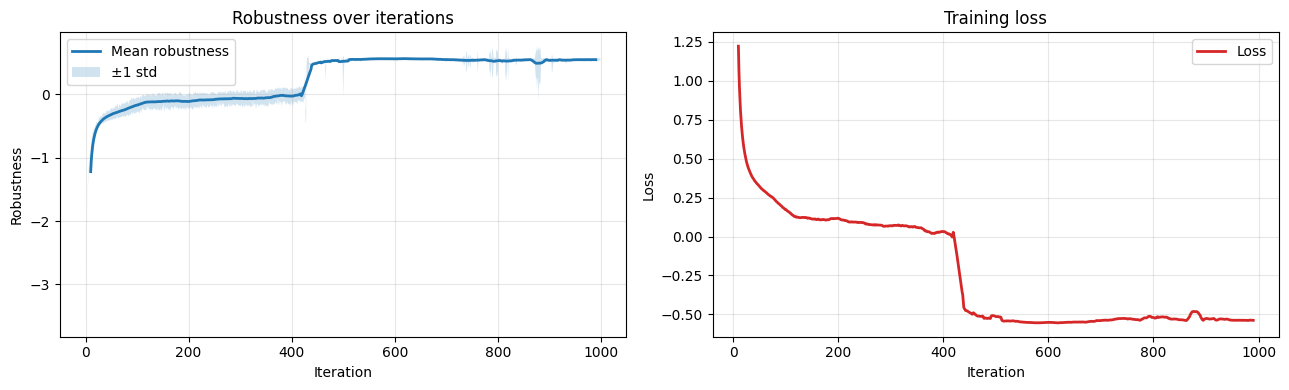

In [7]:
if history is not None:
    stats = pd.DataFrame(history['stats'])
    iters = np.arange(len(stats['mean']))

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    ax[0].plot(iters, stats['mean'].rolling(window=20, center=True).mean(), label='Mean robustness', lw=2)
    ax[0].fill_between(
        iters,
        np.array(stats['mean']) - np.array(stats['std']),
        np.array(stats['mean']) + np.array(stats['std']),
        alpha=0.2, label='±1 std',
    )
    ax[0].set_title('Robustness over iterations')
    ax[0].set_xlabel('Iteration')
    ax[0].set_ylabel('Robustness')
    ax[0].grid(alpha=0.3)
    ax[0].legend()

    ax[1].plot(iters, stats['loss'].rolling(window=20, center=True).mean(), color='tab:red', lw=2, label='Loss')
    ax[1].set_title('Training loss')
    ax[1].set_xlabel('Iteration')
    ax[1].set_ylabel('Loss')
    ax[1].grid(alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('No training history available (pretrained policy loaded).')

In [8]:
# Save policy model (weights only, for inference)
torch.save(policy.state_dict(), 'policy_2.pt')
print("Policy model saved to 'policy_2.pt'")
print(f'Full training checkpoint path: {save_checkpoint_path}')

Policy model saved to 'policy_2.pt'
Full training checkpoint path: policy_checkpoint_2.pt


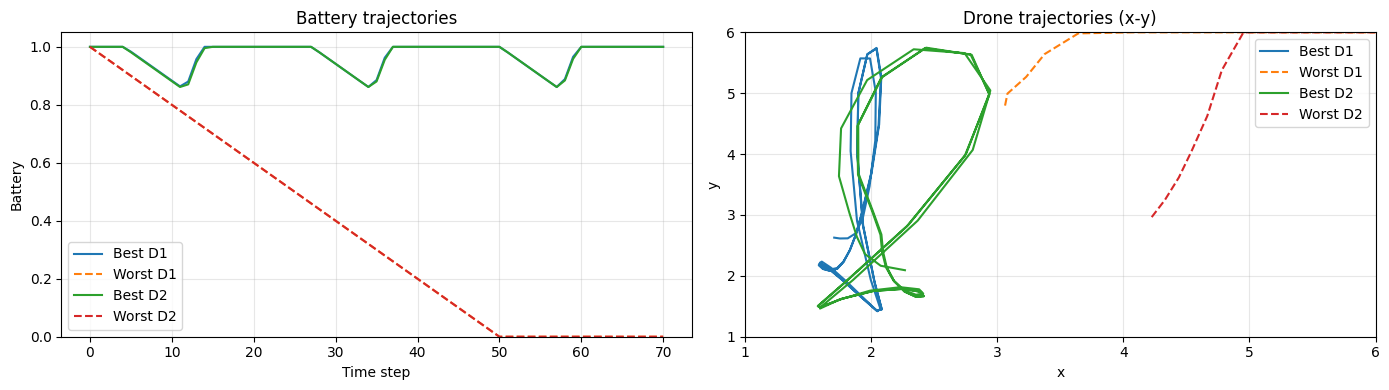

In [9]:
if history is not None:
    def traj_to_np(traj):
        return torch.stack(traj).permute(1, 2, 0).cpu().numpy()

    best_data  = traj_to_np(history['best']['trajectory'])
    worst_data = traj_to_np(history['worst']['trajectory'])
    n_drones_run = int(history['config'].get('n_drones', n_drones))
    drone_idxs   = list(range(best_data.shape[0] - n_drones_run, best_data.shape[0]))

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    for i, idx in enumerate(drone_idxs):
        ax[0].plot(best_data[idx, 4, :],  label=f'Best D{i+1}')
        ax[0].plot(worst_data[idx, 4, :], linestyle='--', label=f'Worst D{i+1}')
    ax[0].set_title('Battery trajectories')
    ax[0].set_xlabel('Time step')
    ax[0].set_ylabel('Battery')
    ax[0].set_ylim(0, 1.05)
    ax[0].grid(alpha=0.3)
    ax[0].legend()

    for i, idx in enumerate(drone_idxs):
        ax[1].plot(best_data[idx, 0, :],  best_data[idx, 1, :],  label=f'Best D{i+1}')
        ax[1].plot(worst_data[idx, 0, :], worst_data[idx, 1, :], linestyle='--', label=f'Worst D{i+1}')
    ax[1].set_xlim(1, grid_side)
    ax[1].set_ylim(1, grid_side)
    ax[1].set_title('Drone trajectories (x-y)')
    ax[1].set_xlabel('x')
    ax[1].set_ylabel('y')
    ax[1].grid(alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('No training history available (pretrained policy loaded).')

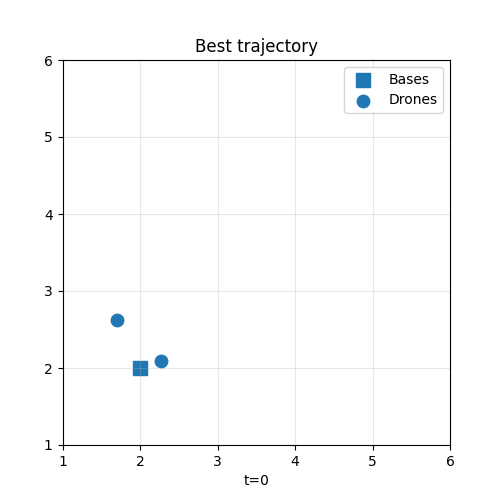

Saved: best_trajectory.gif


In [12]:
# Cell: GIF traiettorie (best episode)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

def traj_to_np(traj):
    # traj: list di tensor (n_nodes, n_feat) oppure (1,n_nodes,n_feat)
    out = []
    for s in traj:
        if s.dim() == 3:
            s = s[0]
        out.append(s.detach().cpu().numpy())
    return np.stack(out, axis=0)  # (T+1, n_nodes, n_feat)

best_np = traj_to_np(history["best"]["trajectory"])
cfg_hist = history["config"]
n_grid = cfg_hist["grid_side"] * cfg_hist["grid_side"]
n_bases = cfg_hist["n_bases"]
n_drones = cfg_hist["n_drones"]

base_idx = np.arange(n_grid, n_grid + n_bases)
drone_idx = np.arange(n_grid + n_bases, n_grid + n_bases + n_drones)

fig, ax = plt.subplots(figsize=(5,5))
ax.set_xlim(1, cfg_hist["grid_side"])
ax.set_ylim(1, cfg_hist["grid_side"])
ax.set_title("Best trajectory")
ax.grid(alpha=0.3)

# basi fisse
ax.scatter(best_np[0, base_idx, 0], best_np[0, base_idx, 1], marker="s", s=100, label="Bases")

drone_sc = ax.scatter([], [], s=80, c="tab:blue", label="Drones")
paths = [ax.plot([], [], lw=2)[0] for _ in range(n_drones)]
ax.legend()

def update(t):
    dxy = best_np[t, drone_idx, 0:2]
    drone_sc.set_offsets(dxy)
    for i, line in enumerate(paths):
        xy = best_np[:t+1, drone_idx[i], 0:2]
        line.set_data(xy[:,0], xy[:,1])
    ax.set_xlabel(f"t={t}")
    return [drone_sc, *paths]

anim = FuncAnimation(fig, update, frames=best_np.shape[0], interval=150, blit=False)
gif_path = "best_trajectory.gif"
anim.save(gif_path, writer=PillowWriter(fps=6))
plt.close(fig)

display(Image(filename=gif_path))
print(f"Saved: {gif_path}")


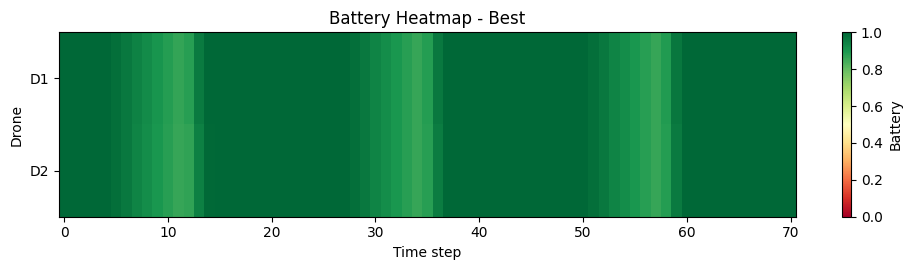

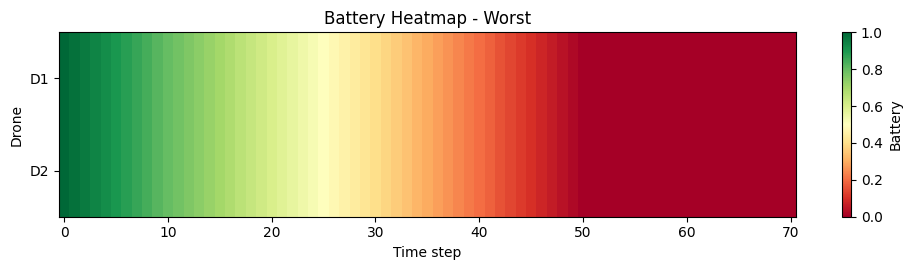

In [14]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Heatmap batteria (stile uguale al tuo)
def battery_heatmap_from_history(traj_list, cfg_hist, title):
    arr = traj_to_np(traj_list)  # (T+1, n_nodes, n_feat)
    n_grid = cfg_hist["grid_side"] * cfg_hist["grid_side"]
    n_bases = cfg_hist["n_bases"]
    n_drones = cfg_hist["n_drones"]
    drone_slice = slice(n_grid + n_bases, n_grid + n_bases + n_drones)

    batt = arr[:, drone_slice, 4].T  # (n_drones, T+1)

    plt.figure(figsize=(10, 2 + 0.4 * n_drones))
    plt.imshow(batt, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    plt.colorbar(label="Battery")
    plt.yticks(np.arange(n_drones), [f"D{i+1}" for i in range(n_drones)])
    plt.xlabel("Time step")
    plt.ylabel("Drone")
    plt.title(title)
    plt.tight_layout()
    plt.show()

battery_heatmap_from_history(history["best"]["trajectory"], history["config"], "Battery Heatmap - Best")
battery_heatmap_from_history(history["worst"]["trajectory"], history["config"], "Battery Heatmap - Worst")


# EVALUATION

In [22]:
# Scenario — must match training
grid_side    = 6
n_bases      = 1
n_drones     = 2
n_feat       = 6
T_total      = 70
action_clip  = 2.0

# Policy architecture — must match training
policy_type   = "mlp"   # "mlp" | "attention"
policy_hidden = 128

# Checkpoint to evaluate
checkpoint_path = "policy_2.pt"

# Evaluation
n_eval_episodes = 100_000   # number of random initial states
eval_batch_size = 256   # how many to run in parallel (reduce if OOM)
init_pos_min    = 1.0
init_pos_max    = 6.0   # same as grid_side

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [23]:
cfg  = ScenarioCfg(grid_side=grid_side, n_bases=n_bases, n_drones=n_drones, n_feat=n_feat)
spec = build_strel_specification(grid_side=cfg.grid_side)

if policy_type == "mlp":
    policy = DroneMLPPolicy(
        n_drones=cfg.n_drones,
        n_bases=cfg.n_bases,
        n_feat=cfg.n_feat,
        hidden=policy_hidden,
        out_channels=2,
        action_scale=action_clip,
    ).to(device)
elif policy_type == "attention":
    policy = DroneAttentionPolicy(
        n_feat=cfg.n_feat,
        action_scale=action_clip,
    ).to(device)
else:
    raise ValueError(f"Unknown policy_type: {policy_type}")

ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
if isinstance(ckpt, dict) and "policy_state_dict" in ckpt:
    state_dict = ckpt["policy_state_dict"]
    ckpt_meta  = ckpt.get("meta", {})
    print(f"Full checkpoint — trained for {ckpt.get('iteration', '?')} iterations")
    if ckpt_meta:
        print("Meta:", ckpt_meta)
else:
    state_dict = ckpt
    print("Plain state-dict checkpoint")

policy.load_state_dict(state_dict)
policy.eval()
n_params = sum(p.numel() for p in policy.parameters())
print(f"Loaded {policy_type} policy — {n_params:,} parameters")

Plain state-dict checkpoint
Loaded mlp policy — 19,076 parameters


In [24]:
def build_initial_state_batch(cfg, device, batch_size, init_pos_min, init_pos_max):
    grid_xy = torch.stack(
        torch.meshgrid(
            torch.linspace(1, cfg.grid_side, cfg.grid_side, device=device),
            torch.linspace(1, cfg.grid_side, cfg.grid_side, device=device),
            indexing='ij',
        ),
        dim=2,
    ).reshape(-1, 2)
    base_positions = _init_base_positions(cfg, device)

    x = torch.zeros((batch_size, cfg.n_nodes, cfg.n_feat), device=device)
    x[:, :cfg.n_grid, 0:2] = grid_xy.unsqueeze(0)
    x[:, :cfg.n_grid, 5]   = 2.0
    x[:, cfg.base_slice, 0:2] = base_positions.unsqueeze(0)
    x[:, cfg.base_slice, 5]   = 0.0
    x[:, cfg.drone_slice, 5]  = 1.0
    x[:, cfg.drone_slice, 4]  = 1.0
    x[:, cfg.drone_slice, 0:2] = (
        torch.rand((batch_size, cfg.n_drones, 2), device=device)
        * (init_pos_max - init_pos_min) + init_pos_min
    )
    return x


all_mean_robs  = []
all_min_robs   = []          # minimum robustness over time per episode
all_robs_time  = []          # (n_episodes, T+1) — per-timestep robustness
all_states     = []          # list of (T+1, batch, n_nodes, n_feat)

n_batches = (n_eval_episodes + eval_batch_size - 1) // eval_batch_size
remaining = n_eval_episodes
with torch.no_grad():
    for _ in tqdm(range(n_batches), desc='Evaluating', unit='batch'):
        bs = min(eval_batch_size, remaining)
        remaining -= bs

        s = build_initial_state_batch(cfg, device, bs, init_pos_min, init_pos_max)
        states = [s]
        for _ in range(T_total):
            a = policy(s, None).clamp(-action_clip, action_clip)
            s = step_dynamics_batched(s, a, cfg)
            states.append(s)

        world = torch.stack(states, dim=0).permute(1, 2, 3, 0)   # (bs, n_nodes, n_feat, T+1)
        rob_map     = spec.quantitative(world, evaluate_at_all_times=True)
        rob_time    = torch.min(rob_map[:, cfg.drone_slice, 0, :], dim=1).values  # (bs, T+1)
        mean_rob    = rob_time.mean(dim=1)                                          # (bs,)

        all_mean_robs.append(mean_rob.cpu())
        all_min_robs.append(rob_time.min(dim=1).values.cpu())
        all_robs_time.append(rob_time.cpu())
        # store states as (T+1, bs, n_nodes, n_feat) on CPU
        all_states.append(torch.stack(states, dim=0).cpu())

mean_robs  = torch.cat(all_mean_robs)    # (n_eval_episodes,)
min_robs   = torch.cat(all_min_robs)     # (n_eval_episodes,)
robs_time  = torch.cat(all_robs_time, dim=0)   # (n_eval_episodes, T+1)

# Concatenate states: list of (T+1, chunk_bs, ...) → (T+1, n_eval_episodes, ...)
states_all = torch.cat(all_states, dim=1)   # (T+1, n_eval_episodes, n_nodes, n_feat)

print(f"Evaluated {n_eval_episodes} episodes")

Evaluating:   0%|          | 0/391 [00:00<?, ?batch/s]

Evaluated 100000 episodes


In [25]:
mean_rob_np = mean_robs.numpy()
min_rob_np  = min_robs.numpy()

success_rate = float((min_robs >= 0).float().mean().item()) * 100   # % episodes where robustness >= 0 at all times

print(f"{'Metric':<35} {'Value':>12}")
print('-' * 50)
print(f"{'Mean robustness (mean over time)':<35} {mean_rob_np.mean():>+12.4f}")
print(f"{'Std robustness':<35} {mean_rob_np.std():>12.4f}")
print(f"{'Median robustness':<35} {np.median(mean_rob_np):>+12.4f}")
print(f"{'Min robustness (worst episode)':<35} {mean_rob_np.min():>+12.4f}")
print(f"{'Max robustness (best episode)':<35} {mean_rob_np.max():>+12.4f}")
print(f"{'10th percentile':<35} {np.percentile(mean_rob_np, 10):>+12.4f}")
print(f"{'25th percentile':<35} {np.percentile(mean_rob_np, 25):>+12.4f}")
print(f"{'75th percentile':<35} {np.percentile(mean_rob_np, 75):>+12.4f}")
print(f"{'90th percentile':<35} {np.percentile(mean_rob_np, 90):>+12.4f}")
print('-' * 50)
print(f"{'Success rate (min rob >= 0) %':<35} {success_rate:>12.1f}")

Metric                                     Value
--------------------------------------------------
Mean robustness (mean over time)         +0.5138
Std robustness                            0.0306
Median robustness                        +0.5119
Min robustness (worst episode)           -0.0076
Max robustness (best episode)            +0.5788
10th percentile                          +0.4793
25th percentile                          +0.5017
75th percentile                          +0.5400
90th percentile                          +0.5469
--------------------------------------------------
Success rate (min rob >= 0) %               73.5


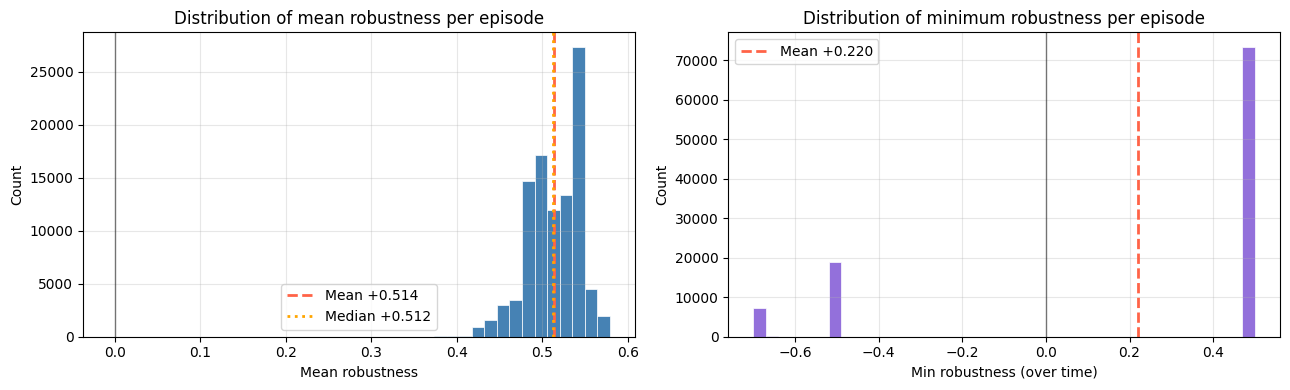

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Mean robustness per episode
ax = axes[0]
ax.hist(mean_rob_np, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(mean_rob_np.mean(), color='tomato', lw=2, linestyle='--', label=f'Mean {mean_rob_np.mean():+.3f}')
ax.axvline(np.median(mean_rob_np), color='orange', lw=2, linestyle=':', label=f'Median {np.median(mean_rob_np):+.3f}')
ax.axvline(0, color='black', lw=1, alpha=0.5, linestyle='-')
ax.set_title('Distribution of mean robustness per episode')
ax.set_xlabel('Mean robustness')
ax.set_ylabel('Count')
ax.legend()
ax.grid(alpha=0.3)

# Minimum robustness per episode (worst time-point)
ax = axes[1]
ax.hist(min_rob_np, bins=40, color='mediumpurple', edgecolor='white', linewidth=0.5)
ax.axvline(min_rob_np.mean(), color='tomato', lw=2, linestyle='--', label=f'Mean {min_rob_np.mean():+.3f}')
ax.axvline(0, color='black', lw=1, alpha=0.5, linestyle='-')
ax.set_title('Distribution of minimum robustness per episode')
ax.set_xlabel('Min robustness (over time)')
ax.set_ylabel('Count')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

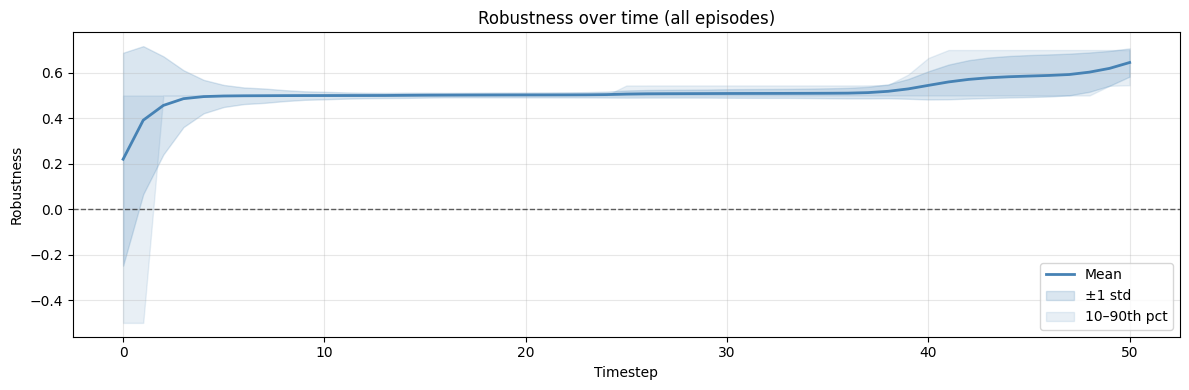

In [27]:
rob_time_np = robs_time.numpy()   # (n_eval_episodes, T+1)
t_axis = np.arange(rob_time_np.shape[1])   # actual length after spec look-ahead

rob_mean = rob_time_np.mean(axis=0)
rob_std  = rob_time_np.std(axis=0)
rob_p10  = np.percentile(rob_time_np, 10, axis=0)
rob_p90  = np.percentile(rob_time_np, 90, axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_axis, rob_mean, lw=2, color='steelblue', label='Mean')
ax.fill_between(t_axis, rob_mean - rob_std, rob_mean + rob_std, alpha=0.2, color='steelblue', label='±1 std')
ax.fill_between(t_axis, rob_p10, rob_p90, alpha=0.12, color='steelblue', label='10–90th pct')
ax.axhline(0, color='black', lw=1, alpha=0.6, linestyle='--')
ax.set_title('Robustness over time (all episodes)')
ax.set_xlabel('Timestep')
ax.set_ylabel('Robustness')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

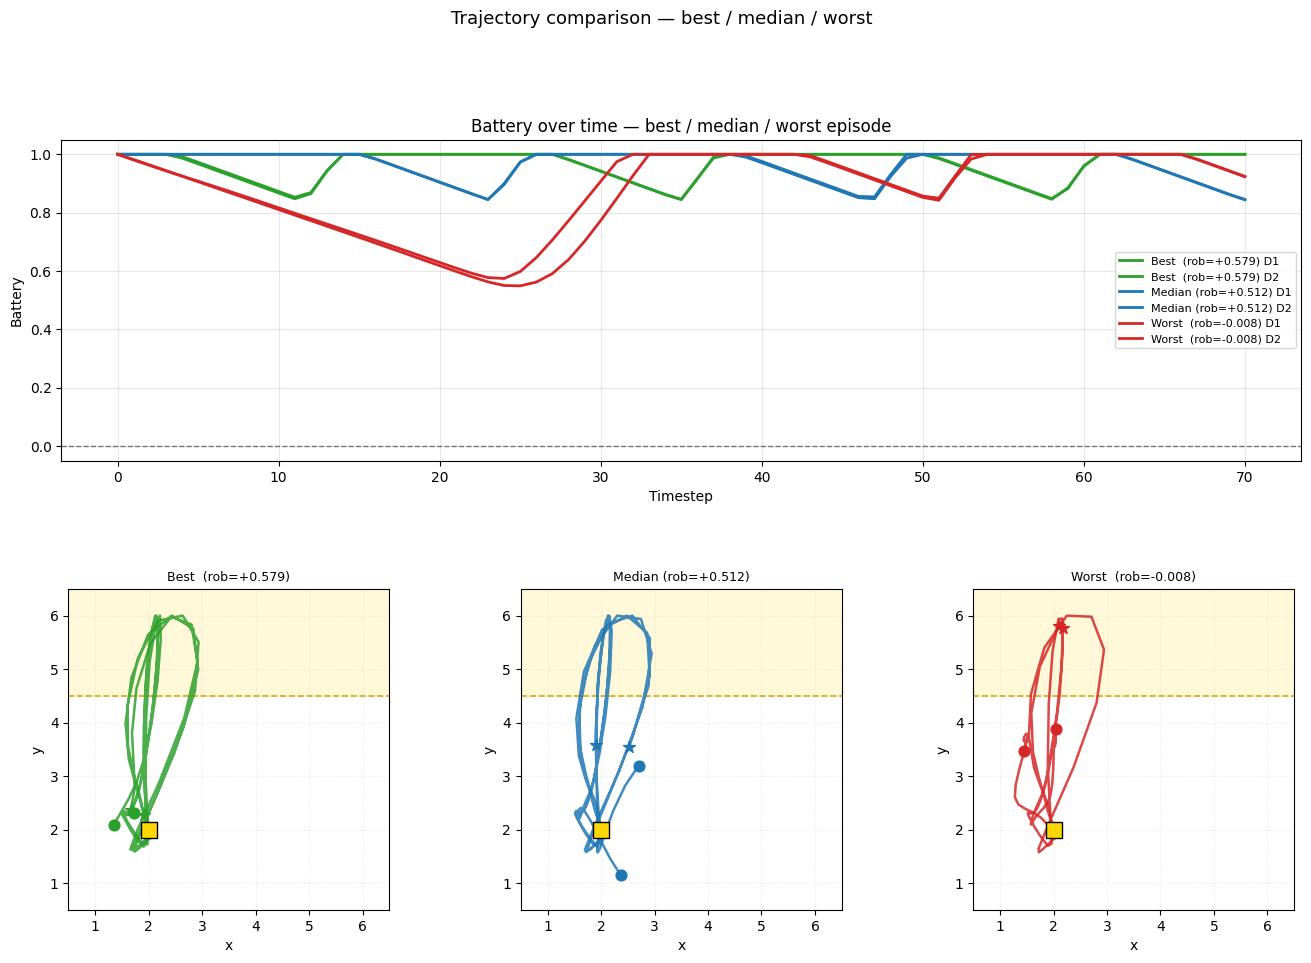

In [29]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm

best_idx   = int(mean_robs.argmax())
worst_idx  = int(mean_robs.argmin())
median_idx = int(np.argsort(mean_rob_np)[len(mean_rob_np) // 2])

episodes = {
    f"Best  (rob={mean_rob_np[best_idx]:+.3f})": best_idx,
    f"Median (rob={mean_rob_np[median_idx]:+.3f})": median_idx,
    f"Worst  (rob={mean_rob_np[worst_idx]:+.3f})": worst_idx,
}
colors_ep = ['tab:green', 'tab:blue', 'tab:red']

# states_all: (T+1, n_eval_episodes, n_nodes, n_feat)
def get_traj_np(ep_idx):
    # returns (n_nodes, n_feat, T+1)
    return states_all[:, ep_idx, :, :].permute(1, 2, 0).numpy()

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax_batt = fig.add_subplot(gs[0, :])
ax_xy   = [fig.add_subplot(gs[1, i]) for i in range(3)]

t_axis = np.arange(T_total + 1)

for (label, ep_idx), color in zip(episodes.items(), colors_ep):
    data = get_traj_np(ep_idx)   # (n_nodes, n_feat, T+1)
    for d in range(cfg.n_drones):
        drone_node = cfg.drone_slice.start + d
        ax_batt.plot(t_axis, data[drone_node, 4, :], color=color, lw=2, label=f'{label} D{d+1}')

ax_batt.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
ax_batt.set_title('Battery over time — best / median / worst episode')
ax_batt.set_xlabel('Timestep')
ax_batt.set_ylabel('Battery')
ax_batt.set_ylim(-0.05, 1.05)
ax_batt.legend(fontsize=8)
ax_batt.grid(alpha=0.3)

base_positions_np = states_all[0, best_idx, cfg.base_slice, 0:2].numpy()

for ax_i, ((label, ep_idx), color) in zip(ax_xy, zip(episodes.items(), colors_ep)):
    data = get_traj_np(ep_idx)
    ax_i.set_xlim(0.5, grid_side + 0.5)
    ax_i.set_ylim(0.5, grid_side + 0.5)
    ax_i.set_aspect('equal')
    ax_i.grid(alpha=0.25, linestyle=':')
    target_y = 0.75 * grid_side
    ax_i.axhspan(target_y, grid_side + 0.5, color='gold', alpha=0.15)
    ax_i.axhline(target_y, color='goldenrod', lw=1.2, linestyle='--')
    # Charging bases
    ax_i.scatter(base_positions_np[:, 0], base_positions_np[:, 1],
                 marker='s', s=120, c='gold', edgecolors='black', zorder=3)
    for d in range(cfg.n_drones):
        drone_node = cfg.drone_slice.start + d
        x_traj = data[drone_node, 0, :]
        y_traj = data[drone_node, 1, :]
        ax_i.plot(x_traj, y_traj, color=color, lw=1.8, alpha=0.85)
        ax_i.scatter(x_traj[0], y_traj[0], color=color, s=60, zorder=4, marker='o')
        ax_i.scatter(x_traj[-1], y_traj[-1], color=color, s=80, zorder=4, marker='*')
    ax_i.set_title(label, fontsize=9)
    ax_i.set_xlabel('x')
    ax_i.set_ylabel('y')

plt.suptitle('Trajectory comparison — best / median / worst', fontsize=13, y=1.01)
plt.show()

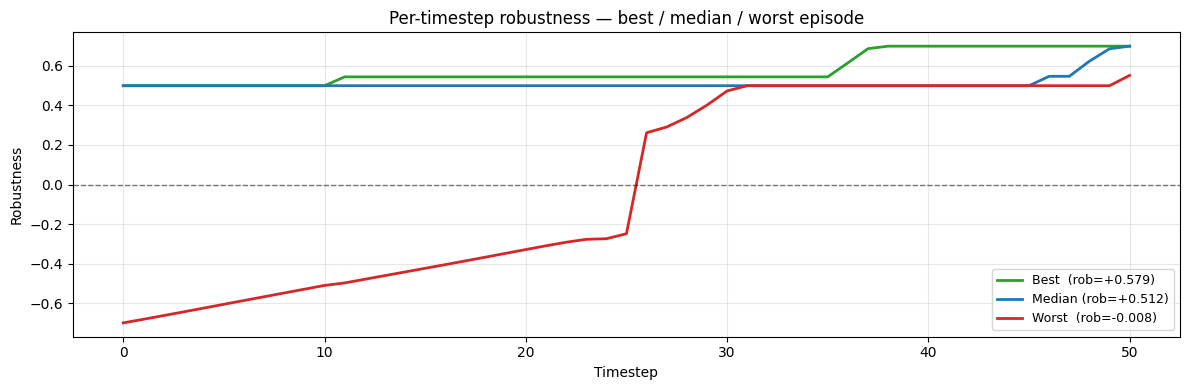

In [30]:
t_axis_rob = np.arange(rob_time_np.shape[1])

fig, ax = plt.subplots(figsize=(12, 4))
for (label, ep_idx), color in zip(episodes.items(), colors_ep):
    ax.plot(t_axis_rob, rob_time_np[ep_idx], color=color, lw=2, label=label)
ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
ax.set_title('Per-timestep robustness — best / median / worst episode')
ax.set_xlabel('Timestep')
ax.set_ylabel('Robustness')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

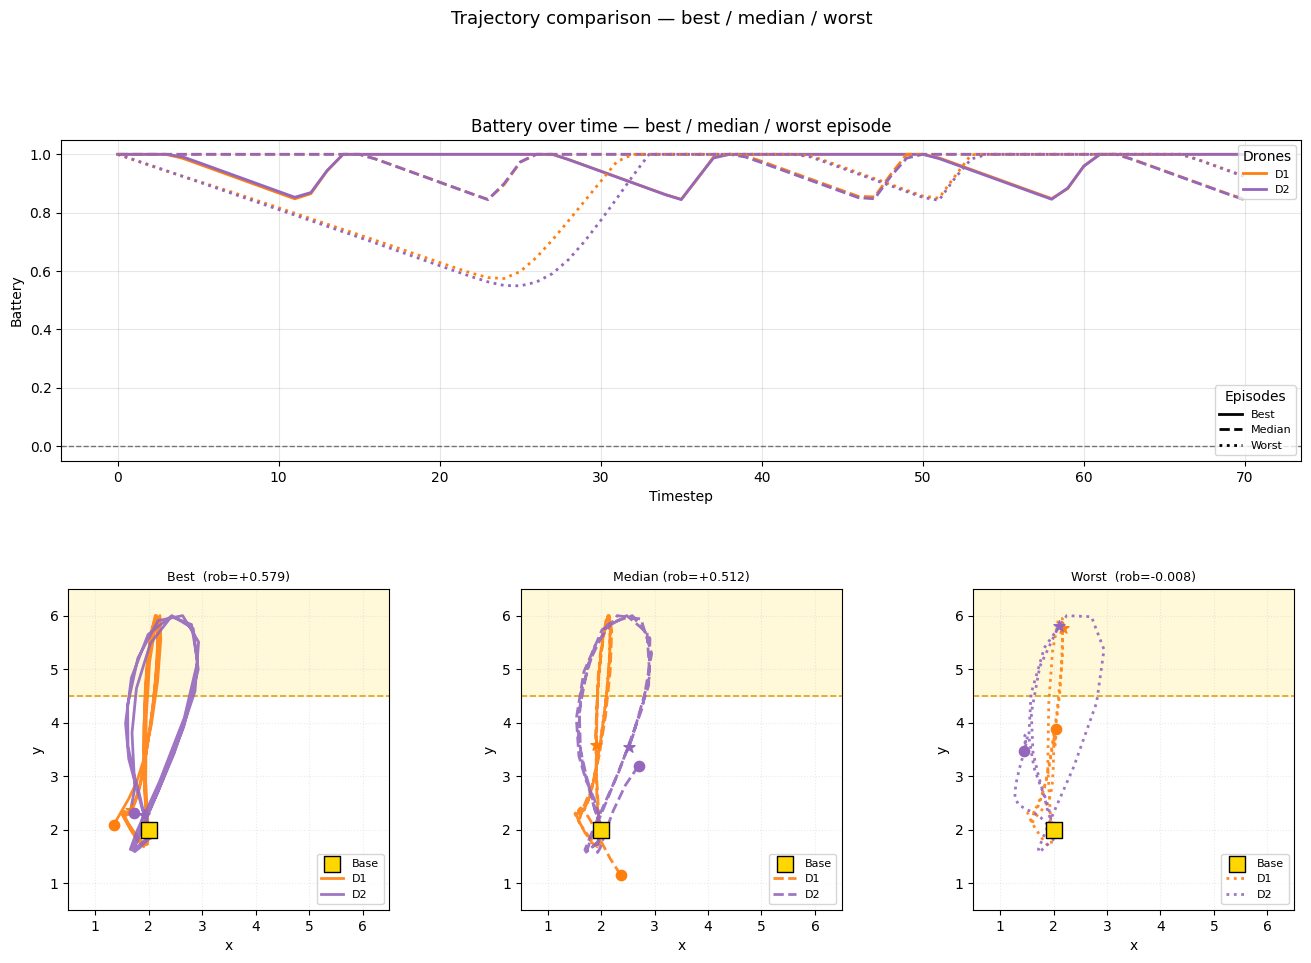

In [32]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm
from matplotlib.lines import Line2D

best_idx   = int(mean_robs.argmax())
worst_idx  = int(mean_robs.argmin())
median_idx = int(np.argsort(mean_rob_np)[len(mean_rob_np) // 2])

episodes = {
    f"Best  (rob={mean_rob_np[best_idx]:+.3f})": best_idx,
    f"Median (rob={mean_rob_np[median_idx]:+.3f})": median_idx,
    f"Worst  (rob={mean_rob_np[worst_idx]:+.3f})": worst_idx,
}
episode_styles = ['-', '--', ':']  # episodio -> stile linea

# drone -> colore fisso
drone_colors = ['tab:orange', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:cyan']

def get_traj_np(ep_idx):
    return states_all[:, ep_idx, :, :].permute(1, 2, 0).numpy()  # (n_nodes, n_feat, T+1)

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax_batt = fig.add_subplot(gs[0, :])
ax_xy   = [fig.add_subplot(gs[1, i]) for i in range(3)]

t_axis = np.arange(T_total + 1)

# Battery: colore=drone, stile=episodio
for ep_i, ((label, ep_idx), ls) in enumerate(zip(episodes.items(), episode_styles)):
    data = get_traj_np(ep_idx)
    for d in range(cfg.n_drones):
        drone_node = cfg.drone_slice.start + d
        dc = drone_colors[d % len(drone_colors)]
        ax_batt.plot(
            t_axis, data[drone_node, 4, :],
            color=dc, linestyle=ls, lw=2,
            label=f'{label} D{d+1}'
        )

ax_batt.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
ax_batt.set_title('Battery over time — best / median / worst episode')
ax_batt.set_xlabel('Timestep')
ax_batt.set_ylabel('Battery')
ax_batt.set_ylim(-0.05, 1.05)
ax_batt.grid(alpha=0.3)

# legenda più leggibile: droni + episodi separati
drone_legend = [
    Line2D([0], [0], color=drone_colors[d % len(drone_colors)], lw=2, label=f'D{d+1}')
    for d in range(cfg.n_drones)
]
ep_legend = [
    Line2D([0], [0], color='black', lw=2, linestyle=ls, label=lab.split('(')[0].strip())
    for (lab, _), ls in zip(episodes.items(), episode_styles)
]
leg1 = ax_batt.legend(handles=drone_legend, title='Drones', loc='upper right', fontsize=8)
ax_batt.add_artist(leg1)
ax_batt.legend(handles=ep_legend, title='Episodes', loc='lower right', fontsize=8)

base_positions_np = states_all[0, best_idx, cfg.base_slice, 0:2].numpy()

# XY: ogni pannello è un episodio; colore fisso per drone
for ax_i, ((label, ep_idx), ls) in zip(ax_xy, zip(episodes.items(), episode_styles)):
    data = get_traj_np(ep_idx)
    ax_i.set_xlim(0.5, grid_side + 0.5)
    ax_i.set_ylim(0.5, grid_side + 0.5)
    ax_i.set_aspect('equal')
    ax_i.grid(alpha=0.25, linestyle=':')
    target_y = 0.75 * grid_side
    ax_i.axhspan(target_y, grid_side + 0.5, color='gold', alpha=0.15)
    ax_i.axhline(target_y, color='goldenrod', lw=1.2, linestyle='--')

    ax_i.scatter(base_positions_np[:, 0], base_positions_np[:, 1],
                 marker='s', s=120, c='gold', edgecolors='black', zorder=3, label='Base')

    for d in range(cfg.n_drones):
        drone_node = cfg.drone_slice.start + d
        x_traj = data[drone_node, 0, :]
        y_traj = data[drone_node, 1, :]
        dc = drone_colors[d % len(drone_colors)]
        ax_i.plot(x_traj, y_traj, color=dc, lw=2, alpha=0.9, linestyle=ls, label=f'D{d+1}')
        ax_i.scatter(x_traj[0], y_traj[0], color=dc, s=55, zorder=4, marker='o')
        ax_i.scatter(x_traj[-1], y_traj[-1], color=dc, s=70, zorder=4, marker='*')

    ax_i.set_title(label, fontsize=9)
    ax_i.set_xlabel('x')
    ax_i.set_ylabel('y')
    ax_i.legend(fontsize=8, loc='lower right')

plt.suptitle('Trajectory comparison — best / median / worst', fontsize=13, y=1.01)
plt.show()
